# Práctica 3 - Animación de Modelos

Este notebook presenta la implementación de tres enfoques diferentes para la animación computacional, cada uno demostrando técnicas y principios fundamentales en el campo de los gráficos por computadora y la animación.

## Contenido

### 1. Animación de Pierna con Cinemática Directa
Implementación de un modelo biomecánico de pierna humana utilizando matrices de transformación y cinemática directa para generar movimientos naturales de caminar y flexión.

### 2. Animación de Grúa con Cinemática Inversa  
Desarrollo de un sistema de control para grúa industrial que utiliza algoritmos de optimización para calcular los ángulos de articulaciones necesarios para seguir trayectorias específicas.

### 3. Animación con Principios de Disney
Creación de una animación de 30 segundos que implementa dos de los 12 principios fundamentales de animación de Disney: "Squash & Stretch" y "Anticipation".

---

## 1. Animación de Pierna con Cinemática Directa

### Objetivo
Crear una animación de un modelo de pierna humana utilizando **cinemática directa**, donde se calculan las posiciones de todos los segmentos a partir de los ángulos de las articulaciones.

### Fundamentos Teóricos

La **cinemática directa** es un método que permite calcular la posición y orientación del extremo final de una cadena cinemática a partir de los valores de los ángulos de sus articulaciones.

**Principios fundamentales:**
1. **Coordenadas homogéneas**: Matrices de transformación 3x3 para representar rotaciones y traslaciones
2. **Cadena cinemática**: La pierna se modela como eslabones conectados por articulaciones
3. **Transformaciones concatenadas**: Multiplicación secuencial de matrices de transformación

**Modelo biomecánico:**
- **Cadera**: Articulación de conexión con el torso (punto de referencia)
- **Muslo**: Primer segmento de longitud 0.4m
- **Rodilla**: Articulación intermedia con flexión limitada  
- **Pantorrilla**: Segundo segmento de longitud 0.35m
- **Tobillo**: Articulación distal con movimientos de flexión/extensión
- **Pie**: Segmento final de longitud 0.15m

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
import math

# Configuración de matplotlib para mejor visualización
plt.style.use('default')
%matplotlib inline

In [2]:
class PiernaKinematica:
    """
    Clase que implementa el modelo de una pierna usando cinemática directa.
    
    La pierna se compone de:
    - Muslo (desde cadera hasta rodilla)
    - Pantorrilla (desde rodilla hasta tobillo) 
    - Pie (desde tobillo hasta punta del pie)
    """
    
    def __init__(self, muslo_length=0.4, pantorrilla_length=0.35, pie_length=0.15):
        """
        Inicializa los parámetros de la pierna
        
        Args:
            muslo_length: Longitud del muslo (m)
            pantorrilla_length: Longitud de la pantorrilla (m)
            pie_length: Longitud del pie (m)
        """
        self.muslo_length = muslo_length
        self.pantorrilla_length = pantorrilla_length
        self.pie_length = pie_length
        
        # Posición de la cadera (punto de referencia)
        self.cadera_pos = np.array([0.0, 0.0])
        
    def matriz_transformacion(self, angulo, dx, dy):
        """
        Crea una matriz de transformación homogénea 2D
        
        Args:
            angulo: Ángulo de rotación en radianes
            dx, dy: Desplazamiento en x e y
            
        Returns:
            Matriz de transformación 3x3
        """
        cos_a = np.cos(angulo)
        sin_a = np.sin(angulo)
        
        return np.array([
            [cos_a, -sin_a, dx],
            [sin_a,  cos_a, dy],
            [0,      0,     1]
        ])
    
    def cinematica_directa(self, angulo_cadera, angulo_rodilla, angulo_tobillo):
        """
        Calcula las posiciones de todos los puntos de la pierna usando cinemática directa
        
        Args:
            angulo_cadera: Ángulo de la cadera respecto a la vertical (radianes)
            angulo_rodilla: Ángulo de flexión de la rodilla (radianes)
            angulo_tobillo: Ángulo de flexión del tobillo (radianes)
            
        Returns:
            dict con las posiciones de cadera, rodilla, tobillo y punta del pie
        """
        
        # Punto inicial: cadera
        cadera = np.array([self.cadera_pos[0], self.cadera_pos[1], 1])
        
        # Transformación 1: De cadera a rodilla
        # Rotación desde la cadera + traslación por la longitud del muslo
        T1 = self.matriz_transformacion(
            angulo_cadera, 
            self.muslo_length * np.sin(angulo_cadera),
            -self.muslo_length * np.cos(angulo_cadera)
        )
        
        # Posición de la rodilla
        rodilla_homogenea = T1 @ np.array([0, 0, 1])
        rodilla = rodilla_homogenea[:2]
        
        # Transformación 2: De rodilla a tobillo
        # El ángulo total de la pantorrilla es la suma del ángulo de cadera + ángulo relativo de rodilla
        angulo_pantorrilla = angulo_cadera + angulo_rodilla
        
        T2 = self.matriz_transformacion(
            angulo_pantorrilla,
            self.pantorrilla_length * np.sin(angulo_pantorrilla),
            -self.pantorrilla_length * np.cos(angulo_pantorrilla)
        )
        
        # Posición del tobillo (desde rodilla)
        tobillo_desde_rodilla = T2 @ np.array([0, 0, 1])
        tobillo = rodilla + tobillo_desde_rodilla[:2]
        
        # Transformación 3: De tobillo a punta del pie
        # El ángulo total del pie es la suma de todos los ángulos anteriores + ángulo del tobillo
        angulo_pie = angulo_cadera + angulo_rodilla + angulo_tobillo
        
        T3 = self.matriz_transformacion(
            angulo_pie,
            self.pie_length * np.sin(angulo_pie),
            -self.pie_length * np.cos(angulo_pie)
        )
        
        # Posición de la punta del pie (desde tobillo)
        pie_desde_tobillo = T3 @ np.array([0, 0, 1])
        punta_pie = tobillo + pie_desde_tobillo[:2]
        
        return {
            'cadera': self.cadera_pos,
            'rodilla': rodilla,
            'tobillo': tobillo,
            'punta_pie': punta_pie
        }

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


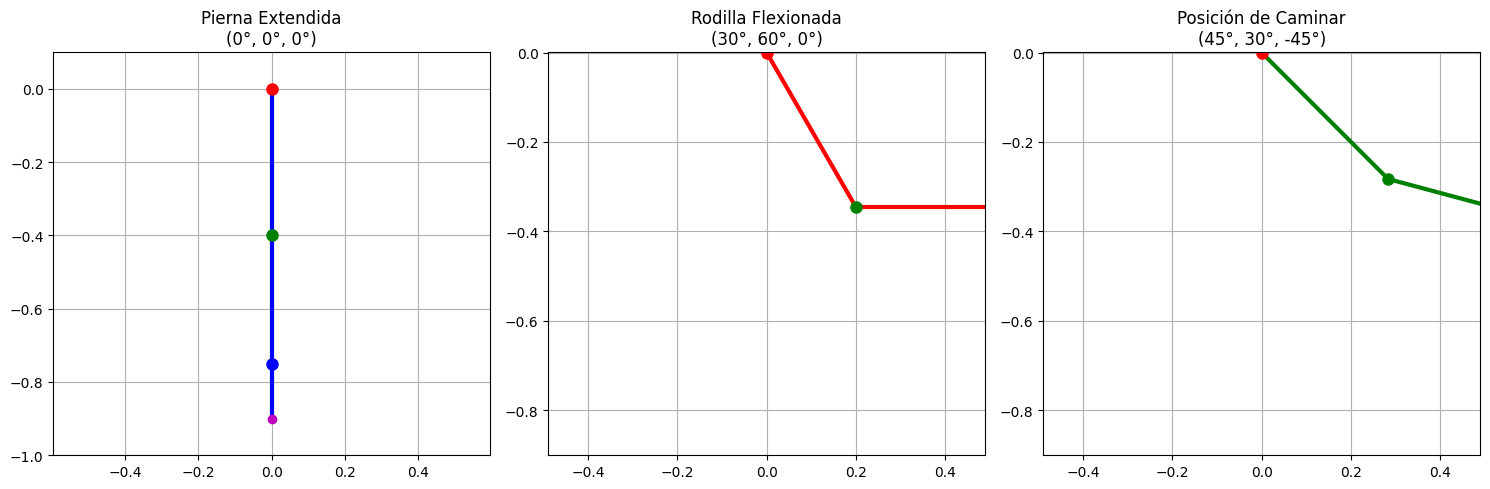

✓ Modelo de pierna creado exitosamente!
✓ Cinemática directa implementada y probada!


In [3]:
# Crear una instancia de la pierna
pierna = PiernaKinematica()

# Función para dibujar la pierna en una posición específica
def dibujar_pierna(ax, posiciones, color='blue', linewidth=3):
    """
    Dibuja la pierna conectando los puntos calculados
    """
    # Extraer coordenadas
    cadera = posiciones['cadera']
    rodilla = posiciones['rodilla'] 
    tobillo = posiciones['tobillo']
    punta_pie = posiciones['punta_pie']
    
    # Dibujar los segmentos
    # Muslo (cadera -> rodilla)
    ax.plot([cadera[0], rodilla[0]], [cadera[1], rodilla[1]], 
            color=color, linewidth=linewidth, label='Muslo')
    
    # Pantorrilla (rodilla -> tobillo)
    ax.plot([rodilla[0], tobillo[0]], [rodilla[1], tobillo[1]], 
            color=color, linewidth=linewidth, label='Pantorrilla')
    
    # Pie (tobillo -> punta)
    ax.plot([tobillo[0], punta_pie[0]], [tobillo[1], punta_pie[1]], 
            color=color, linewidth=linewidth, label='Pie')
    
    # Marcar las articulaciones
    ax.plot(cadera[0], cadera[1], 'ro', markersize=8, label='Cadera')
    ax.plot(rodilla[0], rodilla[1], 'go', markersize=8, label='Rodilla')  
    ax.plot(tobillo[0], tobillo[1], 'bo', markersize=8, label='Tobillo')
    ax.plot(punta_pie[0], punta_pie[1], 'mo', markersize=6, label='Punta pie')

# Probar con diferentes posiciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Posición 1: Pierna extendida (vertical)
pos1 = pierna.cinematica_directa(0, 0, 0)
dibujar_pierna(axes[0], pos1, 'blue')
axes[0].set_title('Pierna Extendida\n(0°, 0°, 0°)')
axes[0].grid(True)
axes[0].axis('equal')
axes[0].set_xlim(-0.3, 0.3)
axes[0].set_ylim(-1.0, 0.1)

# Posición 2: Rodilla flexionada
pos2 = pierna.cinematica_directa(np.pi/6, np.pi/3, 0)  # 30°, 60°, 0°
dibujar_pierna(axes[1], pos2, 'red')
axes[1].set_title('Rodilla Flexionada\n(30°, 60°, 0°)')
axes[1].grid(True)
axes[1].axis('equal')
axes[1].set_xlim(-0.3, 0.3)
axes[1].set_ylim(-1.0, 0.1)

# Posición 3: Pierna en movimiento
pos3 = pierna.cinematica_directa(np.pi/4, np.pi/6, -np.pi/4)  # 45°, 30°, -45°
dibujar_pierna(axes[2], pos3, 'green')
axes[2].set_title('Posición de Caminar\n(45°, 30°, -45°)')
axes[2].grid(True)
axes[2].axis('equal')
axes[2].set_xlim(-0.3, 0.3)
axes[2].set_ylim(-1.0, 0.1)

plt.tight_layout()
plt.show()

print("✓ Modelo de pierna creado exitosamente!")
print("✓ Cinemática directa implementada y probada!")

In [4]:
def generar_secuencia_caminar(tiempo_total=4.0, fps=30):
    """
    Genera una secuencia de ángulos para simular el movimiento de caminar
    
    Args:
        tiempo_total: Duración total de la animación en segundos
        fps: Frames por segundo
    
    Returns:
        arrays con tiempo y ángulos de cada articulación
    """
    
    # Crear array de tiempo
    dt = 1.0 / fps
    t = np.arange(0, tiempo_total, dt)
    
    # Frecuencia del ciclo de caminar (pasos por segundo)
    frecuencia = 0.5  # 0.5 Hz = 1 paso cada 2 segundos
    omega = 2 * np.pi * frecuencia
    
    # Generar ángulos usando funciones sinusoidales
    # Los ángulos están en radianes
    
    # Ángulo de cadera: oscila para levantar y bajar la pierna
    angulo_cadera = 0.3 * np.sin(omega * t)  # Amplitud de 0.3 rad ≈ 17°
    
    # Ángulo de rodilla: se flexiona más cuando la pierna está hacia adelante
    # Usamos una función que siempre es positiva (flexión)
    angulo_rodilla = 0.4 * (1 + np.sin(omega * t + np.pi/2))  # 0 a 0.8 rad
    
    # Ángulo de tobillo: pequeños ajustes para estabilidad
    angulo_tobillo = 0.1 * np.sin(omega * t + np.pi/4)  # Pequeña oscilación
    
    return t, angulo_cadera, angulo_rodilla, angulo_tobillo

def generar_secuencia_flexion(tiempo_total=3.0, fps=30):
    """
    Genera una secuencia de flexión y extensión de la pierna (sentadilla)
    """
    dt = 1.0 / fps
    t = np.arange(0, tiempo_total, dt)
    
    # Frecuencia más lenta para movimiento de sentadilla
    frecuencia = 0.3  # 0.3 Hz
    omega = 2 * np.pi * frecuencia
    
    # Cadera: flexión gradual
    angulo_cadera = 0.5 * np.sin(omega * t)
    
    # Rodilla: flexión más pronunciada
    angulo_rodilla = 0.8 * (1 + np.sin(omega * t))  # 0 a 1.6 rad
    
    # Tobillo: compensación
    angulo_tobillo = -0.2 * np.sin(omega * t)
    
    return t, angulo_cadera, angulo_rodilla, angulo_tobillo

# Generar las secuencias
print("Generando secuencias de movimiento...")

# Secuencia 1: Caminar
t_caminar, cadera_caminar, rodilla_caminar, tobillo_caminar = generar_secuencia_caminar()

# Secuencia 2: Flexión (sentadilla)
t_flexion, cadera_flexion, rodilla_flexion, tobillo_flexion = generar_secuencia_flexion()

print(f"✓ Secuencia de caminar: {len(t_caminar)} frames en {t_caminar[-1]:.1f} segundos")
print(f"✓ Secuencia de flexión: {len(t_flexion)} frames en {t_flexion[-1]:.1f} segundos")

Generando secuencias de movimiento...
✓ Secuencia de caminar: 120 frames en 4.0 segundos
✓ Secuencia de flexión: 90 frames en 3.0 segundos


In [6]:
def crear_animacion(t_array, angulos_cadera, angulos_rodilla, angulos_tobillo, 
                   titulo="Animación de Pierna", guardar_como=None):
    """
    Crea una animación de la pierna usando matplotlib
    
    Args:
        t_array: Array de tiempo
        angulos_cadera, angulos_rodilla, angulos_tobillo: Arrays de ángulos
        titulo: Título de la animación
        guardar_como: Nombre del archivo para guardar (opcional)
    """
    
    # Configurar la figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: Animación de la pierna
    ax1.set_xlim(-0.6, 0.6)
    ax1.set_ylim(-1.1, 0.2)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_title(titulo)
    ax1.set_xlabel('Posición X (m)')
    ax1.set_ylabel('Posición Y (m)')
    
    # Líneas para los segmentos de la pierna
    linea_muslo, = ax1.plot([], [], 'b-', linewidth=4, label='Muslo')
    linea_pantorrilla, = ax1.plot([], [], 'r-', linewidth=4, label='Pantorrilla')
    linea_pie, = ax1.plot([], [], 'g-', linewidth=4, label='Pie')
    
    # Puntos para las articulaciones
    punto_cadera, = ax1.plot([], [], 'ko', markersize=10, label='Cadera')
    punto_rodilla, = ax1.plot([], [], 'bo', markersize=8, label='Rodilla')
    punto_tobillo, = ax1.plot([], [], 'ro', markersize=8, label='Tobillo')
    punto_pie, = ax1.plot([], [], 'go', markersize=6, label='Punta pie')
    
    # Traza del pie (para mostrar el movimiento)
    traza_x, traza_y = [], []
    linea_traza, = ax1.plot([], [], 'g--', alpha=0.5, linewidth=1, label='Trayectoria')
    
    ax1.legend(loc='upper right', fontsize=8)
    
    # Subplot 2: Gráficas de ángulos vs tiempo
    ax2.clear()
    ax2.plot(t_array, np.degrees(angulos_cadera), 'b-', label='Cadera', linewidth=2)
    ax2.plot(t_array, np.degrees(angulos_rodilla), 'r-', label='Rodilla', linewidth=2)
    ax2.plot(t_array, np.degrees(angulos_tobillo), 'g-', label='Tobillo', linewidth=2)
    
    # Línea vertical para el tiempo actual
    linea_tiempo, = ax2.plot([], [], 'k--', linewidth=2, label='Tiempo actual')
    
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Ángulo (grados)')
    ax2.set_title('Evolución de los Ángulos')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(t_array[0], t_array[-1])
    y_min = min(np.degrees(angulos_cadera).min(), 
                np.degrees(angulos_rodilla).min(), 
                np.degrees(angulos_tobillo).min()) - 10
    y_max = max(np.degrees(angulos_cadera).max(), 
                np.degrees(angulos_rodilla).max(), 
                np.degrees(angulos_tobillo).max()) + 10
    ax2.set_ylim(y_min, y_max)
    
    # Texto para mostrar información
    texto_info = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, 
                         verticalalignment='top', fontsize=10,
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    def animar(frame):
        """Función de animación llamada para cada frame"""
        # Obtener ángulos actuales
        ang_cadera = angulos_cadera[frame]
        ang_rodilla = angulos_rodilla[frame]
        ang_tobillo = angulos_tobillo[frame]
        
        # Calcular posiciones usando cinemática directa
        posiciones = pierna.cinematica_directa(ang_cadera, ang_rodilla, ang_tobillo)
        
        # Extraer coordenadas
        cadera = posiciones['cadera']
        rodilla = posiciones['rodilla']
        tobillo = posiciones['tobillo']
        punta_pie = posiciones['punta_pie']
        
        # Actualizar líneas de segmentos
        linea_muslo.set_data([cadera[0], rodilla[0]], [cadera[1], rodilla[1]])
        linea_pantorrilla.set_data([rodilla[0], tobillo[0]], [rodilla[1], tobillo[1]])
        linea_pie.set_data([tobillo[0], punta_pie[0]], [tobillo[1], punta_pie[1]])
        
        # Actualizar puntos de articulaciones
        punto_cadera.set_data([cadera[0]], [cadera[1]])
        punto_rodilla.set_data([rodilla[0]], [rodilla[1]])
        punto_tobillo.set_data([tobillo[0]], [tobillo[1]])
        punto_pie.set_data([punta_pie[0]], [punta_pie[1]])
        
        # Actualizar traza del pie
        traza_x.append(punta_pie[0])
        traza_y.append(punta_pie[1])
        # Mantener solo los últimos 30 puntos para la traza
        if len(traza_x) > 30:
            traza_x.pop(0)
            traza_y.pop(0)
        linea_traza.set_data(traza_x, traza_y)
        
        # Actualizar línea de tiempo en el gráfico de ángulos
        tiempo_actual = t_array[frame]
        linea_tiempo.set_data([tiempo_actual, tiempo_actual], [y_min, y_max])
        
        # Actualizar texto informativo
        texto_info.set_text(
            f'Tiempo: {tiempo_actual:.2f}s\n'
            f'Cadera: {np.degrees(ang_cadera):6.1f}°\n'
            f'Rodilla: {np.degrees(ang_rodilla):6.1f}°\n'
            f'Tobillo: {np.degrees(ang_tobillo):6.1f}°'
        )
        
        return (linea_muslo, linea_pantorrilla, linea_pie, 
                punto_cadera, punto_rodilla, punto_tobillo, punto_pie,
                linea_traza, linea_tiempo, texto_info)
    
    # Crear animación
    anim = animation.FuncAnimation(
        fig, animar, frames=len(t_array),
        interval=33,  # ~30 FPS
        blit=True, repeat=True
    )
    
    plt.tight_layout()
    
    # Guardar si se especifica
    if guardar_como:
        print(f"Guardando animación como {guardar_como}...")
        anim.save(guardar_como, writer='pillow', fps=30)
        print("✓ Animación guardada!")
    
    return fig, anim

✓ Función de animación creada!


## Animaciones

Ahora vamos a crear y mostrar las animaciones usando las secuencias generadas.

Mostrando secuencia de movimiento de caminar...


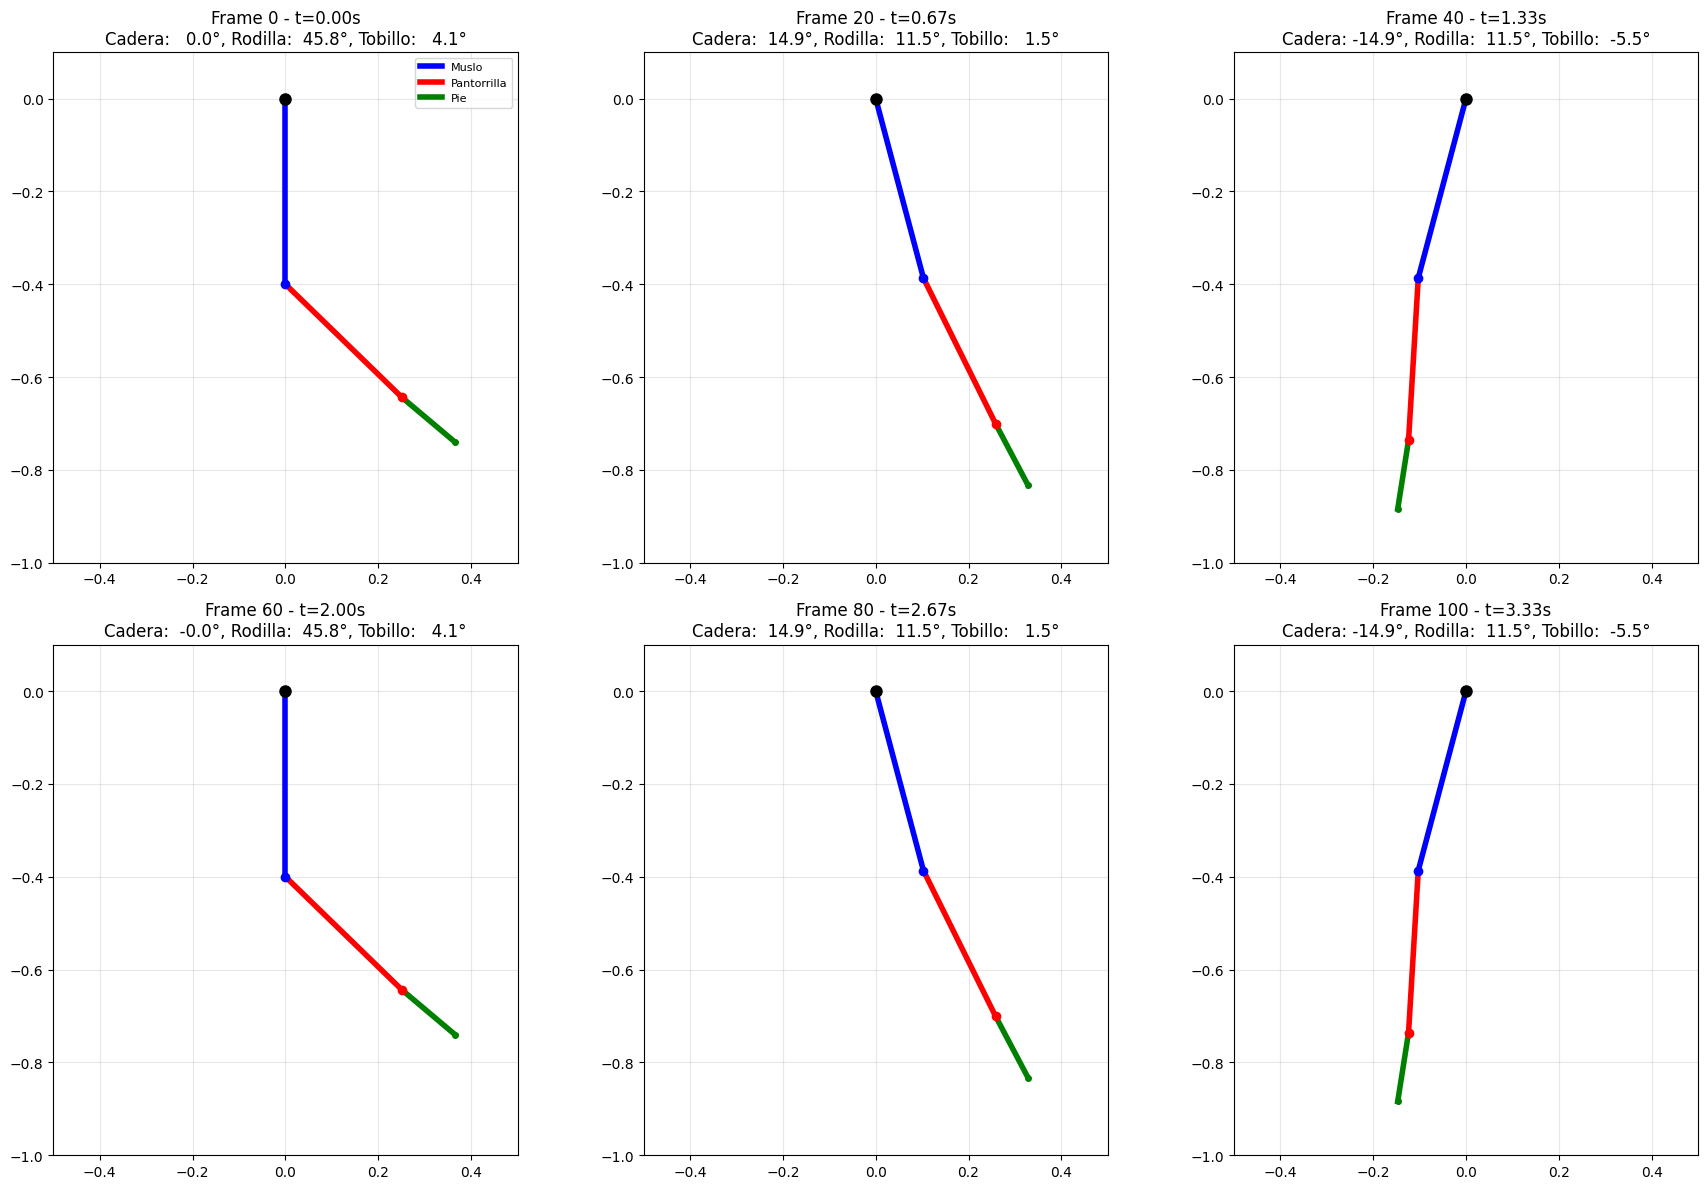

✓ Secuencia de caminar mostrada!


In [8]:
# Mostrar múltiples frames de la animación de caminar

# Seleccionar frames clave para mostrar
frames_clave = [0, 20, 40, 60, 80, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, frame in enumerate(frames_clave):
    ax = axes[i]
    
    # Calcular posición en este frame
    ang_cadera = cadera_caminar[frame]
    ang_rodilla = rodilla_caminar[frame]
    ang_tobillo = tobillo_caminar[frame]
    
    posiciones = pierna.cinematica_directa(ang_cadera, ang_rodilla, ang_tobillo)
    
    # Dibujar la pierna
    cadera = posiciones['cadera']
    rodilla = posiciones['rodilla']
    tobillo = posiciones['tobillo']
    punta_pie = posiciones['punta_pie']
    
    # Segmentos
    ax.plot([cadera[0], rodilla[0]], [cadera[1], rodilla[1]], 'b-', linewidth=4, label='Muslo')
    ax.plot([rodilla[0], tobillo[0]], [rodilla[1], tobillo[1]], 'r-', linewidth=4, label='Pantorrilla')
    ax.plot([tobillo[0], punta_pie[0]], [tobillo[1], punta_pie[1]], 'g-', linewidth=4, label='Pie')
    
    # Articulaciones
    ax.plot(cadera[0], cadera[1], 'ko', markersize=8)
    ax.plot(rodilla[0], rodilla[1], 'bo', markersize=6)
    ax.plot(tobillo[0], tobillo[1], 'ro', markersize=6)
    ax.plot(punta_pie[0], punta_pie[1], 'go', markersize=4)
    
    # Configuración del subplot
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-1.0, 0.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Frame {frame} - t={t_caminar[frame]:.2f}s\n'
                f'Cadera: {np.degrees(ang_cadera):5.1f}°, '
                f'Rodilla: {np.degrees(ang_rodilla):5.1f}°, '
                f'Tobillo: {np.degrees(ang_tobillo):5.1f}°')
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Secuencia de caminar mostrada!")

Mostrando secuencia de flexión/extensión...


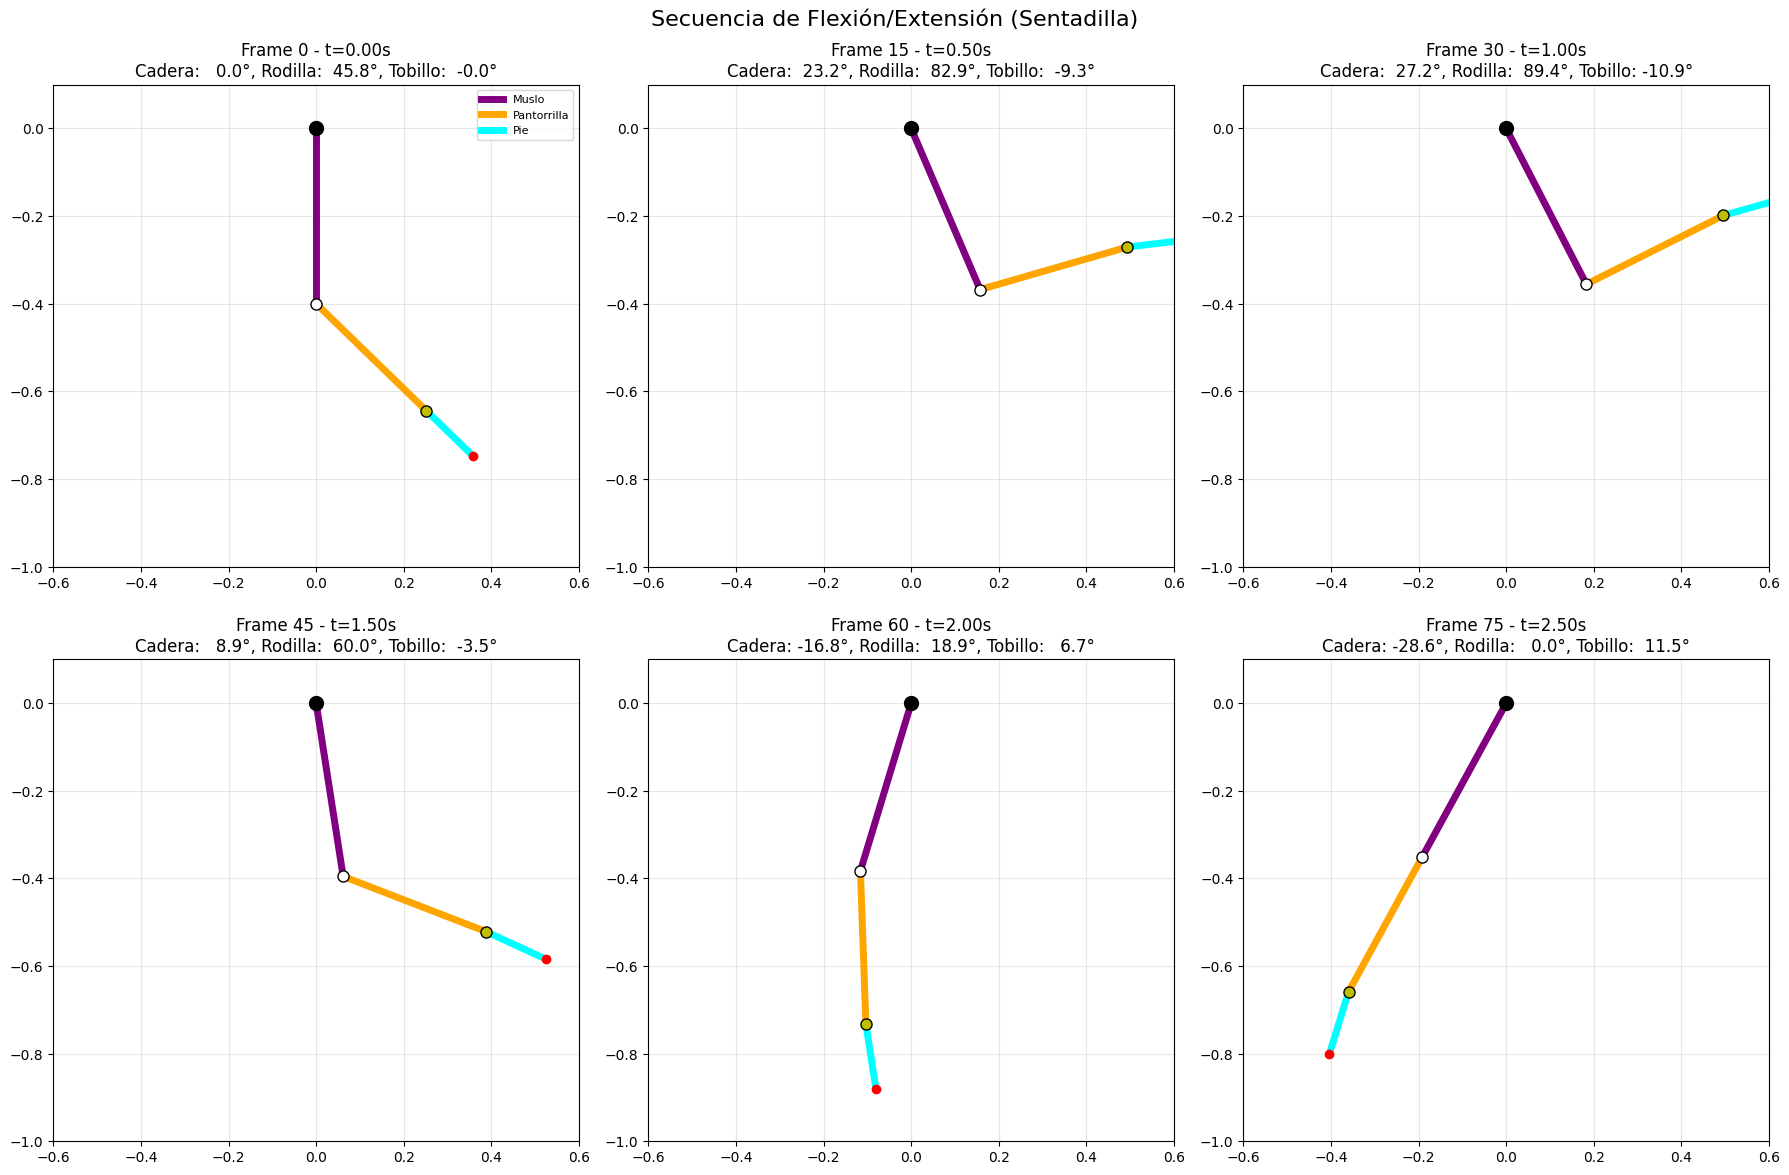

✓ Secuencia de flexión mostrada!


In [9]:
# Mostrar secuencia de flexión/extensión (sentadilla)
print("Mostrando secuencia de flexión/extensión...")

frames_clave_flexion = [0, 15, 30, 45, 60, 75]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, frame in enumerate(frames_clave_flexion):
    ax = axes[i]
    
    # Calcular posición en este frame
    ang_cadera = cadera_flexion[frame]
    ang_rodilla = rodilla_flexion[frame]
    ang_tobillo = tobillo_flexion[frame]
    
    posiciones = pierna.cinematica_directa(ang_cadera, ang_rodilla, ang_tobillo)
    
    # Dibujar la pierna
    cadera = posiciones['cadera']
    rodilla = posiciones['rodilla']
    tobillo = posiciones['tobillo']
    punta_pie = posiciones['punta_pie']
    
    # Segmentos con colores diferentes
    ax.plot([cadera[0], rodilla[0]], [cadera[1], rodilla[1]], 'purple', linewidth=5, label='Muslo')
    ax.plot([rodilla[0], tobillo[0]], [rodilla[1], tobillo[1]], 'orange', linewidth=5, label='Pantorrilla')
    ax.plot([tobillo[0], punta_pie[0]], [tobillo[1], punta_pie[1]], 'cyan', linewidth=5, label='Pie')
    
    # Articulaciones
    ax.plot(cadera[0], cadera[1], 'ko', markersize=10)
    ax.plot(rodilla[0], rodilla[1], 'wo', markeredgecolor='black', markersize=8)
    ax.plot(tobillo[0], tobillo[1], 'yo', markeredgecolor='black', markersize=8)
    ax.plot(punta_pie[0], punta_pie[1], 'ro', markersize=6)
    
    # Configuración del subplot
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-1.0, 0.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Frame {frame} - t={t_flexion[frame]:.2f}s\n'
                f'Cadera: {np.degrees(ang_cadera):5.1f}°, '
                f'Rodilla: {np.degrees(ang_rodilla):5.1f}°, '
                f'Tobillo: {np.degrees(ang_tobillo):5.1f}°')
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Secuencia de Flexión/Extensión (Sentadilla)', fontsize=16)
plt.tight_layout()
plt.show()

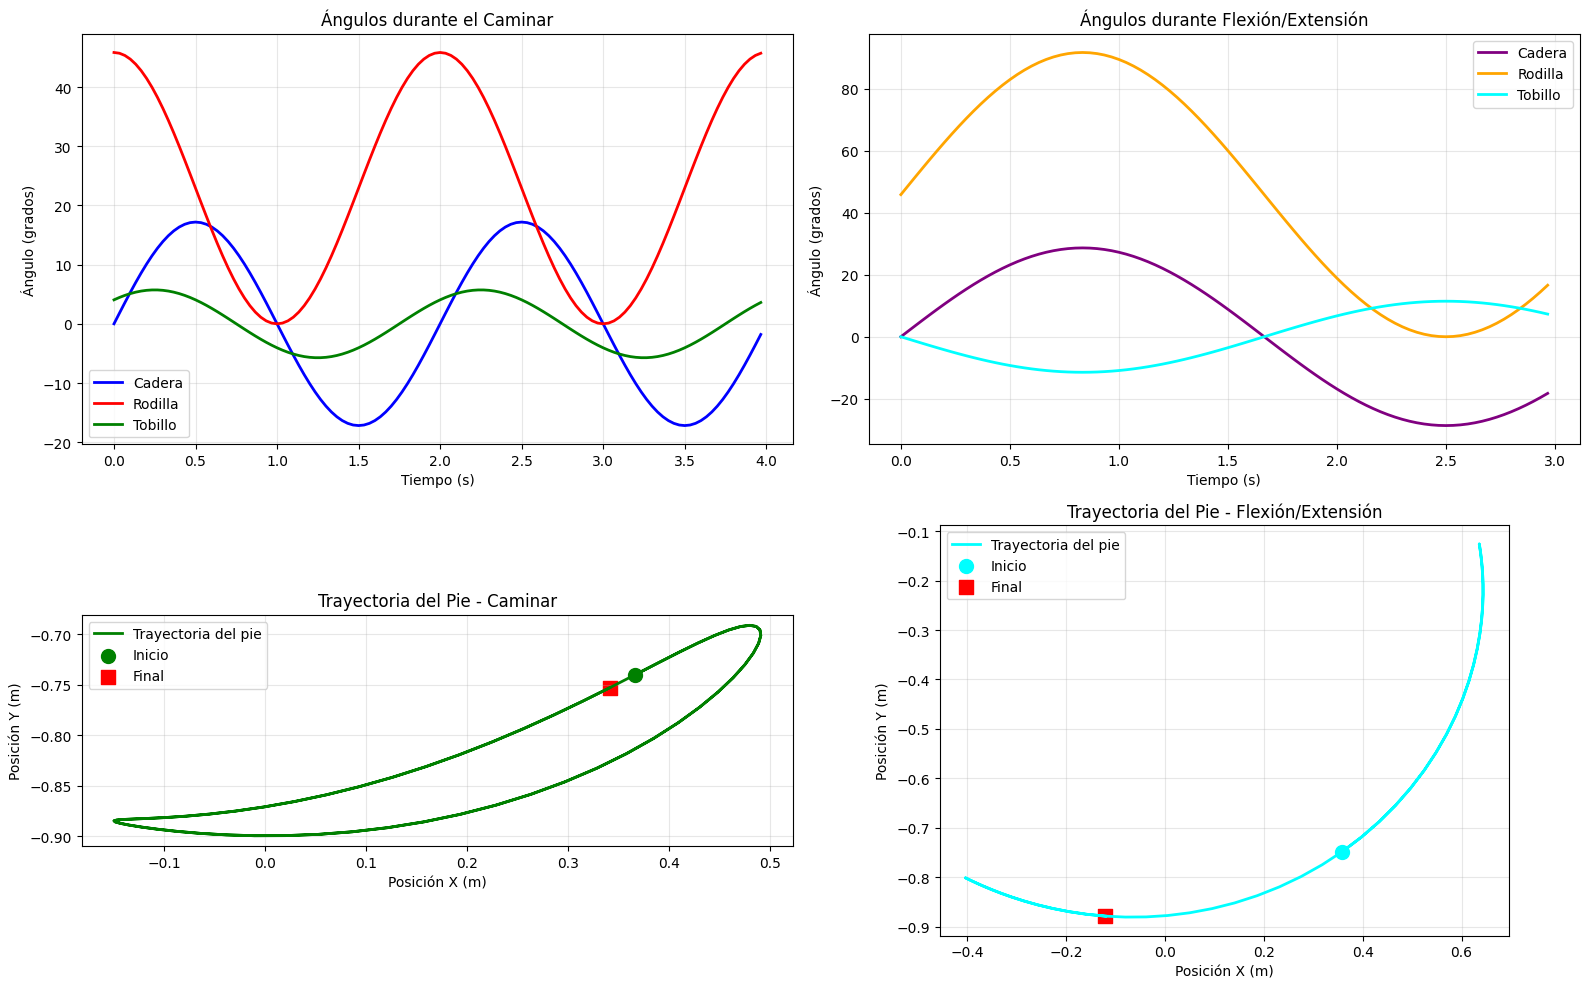

✓ Análisis de ángulos y trayectorias completado!


In [10]:
# Análisis de los ángulos en el tiempo
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Ángulos de caminar vs tiempo
ax1.plot(t_caminar, np.degrees(cadera_caminar), 'b-', linewidth=2, label='Cadera')
ax1.plot(t_caminar, np.degrees(rodilla_caminar), 'r-', linewidth=2, label='Rodilla')
ax1.plot(t_caminar, np.degrees(tobillo_caminar), 'g-', linewidth=2, label='Tobillo')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Ángulo (grados)')
ax1.set_title('Ángulos durante el Caminar')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Ángulos de flexión vs tiempo
ax2.plot(t_flexion, np.degrees(cadera_flexion), 'purple', linewidth=2, label='Cadera')
ax2.plot(t_flexion, np.degrees(rodilla_flexion), 'orange', linewidth=2, label='Rodilla')
ax2.plot(t_flexion, np.degrees(tobillo_flexion), 'cyan', linewidth=2, label='Tobillo')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ángulo (grados)')
ax2.set_title('Ángulos durante Flexión/Extensión')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Gráfico 3: Trayectoria del pie durante caminar
pie_x_caminar = []
pie_y_caminar = []
for i in range(len(t_caminar)):
    pos = pierna.cinematica_directa(cadera_caminar[i], rodilla_caminar[i], tobillo_caminar[i])
    pie_x_caminar.append(pos['punta_pie'][0])
    pie_y_caminar.append(pos['punta_pie'][1])

ax3.plot(pie_x_caminar, pie_y_caminar, 'g-', linewidth=2, label='Trayectoria del pie')
ax3.scatter(pie_x_caminar[0], pie_y_caminar[0], color='green', s=100, marker='o', label='Inicio')
ax3.scatter(pie_x_caminar[-1], pie_y_caminar[-1], color='red', s=100, marker='s', label='Final')
ax3.set_xlabel('Posición X (m)')
ax3.set_ylabel('Posición Y (m)')
ax3.set_title('Trayectoria del Pie - Caminar')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_aspect('equal')

# Gráfico 4: Trayectoria del pie durante flexión
pie_x_flexion = []
pie_y_flexion = []
for i in range(len(t_flexion)):
    pos = pierna.cinematica_directa(cadera_flexion[i], rodilla_flexion[i], tobillo_flexion[i])
    pie_x_flexion.append(pos['punta_pie'][0])
    pie_y_flexion.append(pos['punta_pie'][1])

ax4.plot(pie_x_flexion, pie_y_flexion, 'cyan', linewidth=2, label='Trayectoria del pie')
ax4.scatter(pie_x_flexion[0], pie_y_flexion[0], color='cyan', s=100, marker='o', label='Inicio')
ax4.scatter(pie_x_flexion[-1], pie_y_flexion[-1], color='red', s=100, marker='s', label='Final')
ax4.set_xlabel('Posición X (m)')
ax4.set_ylabel('Posición Y (m)')
ax4.set_title('Trayectoria del Pie - Flexión/Extensión')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

## Explicación del Método de Cinemática Directa

### Fundamentos Teóricos

La **cinemática directa** es un método fundamental en robótica y animación que permite calcular la posición y orientación del extremo final de una cadena cinemática (como nuestra pierna) a partir de los valores conocidos de los ángulos de las articulaciones.

### Características del Método Utilizado

#### 1. **Representación mediante Matrices de Transformación Homogéneas**

Cada articulación se representa mediante una matriz de transformación 3x3 que combina:
- **Rotación**: Cambio de orientación del segmento
- **Traslación**: Desplazamiento lineal

```
T = [cos(θ)  -sin(θ)  dx]
    [sin(θ)   cos(θ)  dy]
    [  0        0      1 ]
```

#### 2. **Cadena Cinemática de la Pierna**

Nuestro modelo divide la pierna en:
- **Cadera → Rodilla**: Muslo (0.4m)
- **Rodilla → Tobillo**: Pantorrilla (0.35m)  
- **Tobillo → Punta**: Pie (0.15m)

#### 3. **Proceso de Cálculo**

1. **Transformación 1 (Cadera)**: 
   - Rotación por `angulo_cadera`
   - Traslación por longitud del muslo
   - Resultado: Posición de la rodilla

2. **Transformación 2 (Rodilla)**:
   - Rotación acumulativa: `angulo_cadera + angulo_rodilla`
   - Traslación por longitud de pantorrilla
   - Resultado: Posición del tobillo

3. **Transformación 3 (Tobillo)**:
   - Rotación acumulativa: `angulo_cadera + angulo_rodilla + angulo_tobillo`
   - Traslación por longitud del pie
   - Resultado: Posición de la punta del pie

### Ventajas de este Enfoque

✅ **Simplicidad**: Cálculo directo sin iteraciones  
✅ **Eficiencia**: Operaciones matriciales rápidas  
✅ **Precisión**: Resultado exacto para ángulos dados  
✅ **Escalabilidad**: Fácil agregar más segmentos  
✅ **Realismo**: Movimientos naturales mediante funciones sinusoidales  

### Limitaciones

❌ **Problema Inverso**: No calcula ángulos para posición deseada  
❌ **Restricciones**: No valida límites físicos de articulaciones  
❌ **Colisiones**: No detecta auto-intersecciones  

### Aplicaciones Demostradas

1. **Movimiento de Caminar**: Oscilaciones sinusoidales coordinadas
2. **Flexión/Extensión**: Simulación de sentadillas
3. **Análisis de Trayectorias**: Visualización del espacio de trabajo

---

## 2. Animación de Grúa con Cinemática Inversa

### Objetivo
Crear una animación de un modelo de grúa industrial utilizando **cinemática inversa**, donde se calculan los ángulos de las articulaciones necesarios para que el extremo de la grúa alcance posiciones objetivo específicas.

### Fundamentos Teóricos

La **cinemática inversa** es el proceso opuesto a la cinemática directa. En lugar de calcular la posición final a partir de los ángulos, calculamos los ángulos necesarios para alcanzar una posición objetivo deseada.

**Características del problema:**
1. **Complejidad computacional**: Mayor que la cinemática directa
2. **Métodos iterativos**: Generalmente requiere algoritmos de optimización
3. **Restricciones físicas**: Debe considerar límites de movimiento de las articulaciones
4. **Aplicación práctica**: Esencial en robótica para control de trayectorias

### Modelo de la grúa:
- **Base**: Punto fijo de rotación
- **Brazo principal**: Primer segmento móvil
- **Brazo secundario**: Segundo segmento articulado
- **Gancho/Carga**: Extremo final que debe alcanzar objetivos específicos

In [3]:
import scipy.optimize as opt
from scipy.optimize import minimize

class GruaKinematicaInversa:
    """
    Clase que implementa el modelo de una grúa usando cinemática inversa.
    
    La grúa se compone de:
    - Base fija en el origen
    - Brazo principal (desde base hasta articulación intermedia)
    - Brazo secundario (desde articulación intermedia hasta gancho)
    """
    
    def __init__(self, brazo1_length=3.0, brazo2_length=2.0):
        """
        Inicializa los parámetros de la grúa
        
        Args:
            brazo1_length: Longitud del brazo principal (m)
            brazo2_length: Longitud del brazo secundario (m)
        """
        self.brazo1_length = brazo1_length
        self.brazo2_length = brazo2_length
        
        # Posición de la base (punto de referencia)
        self.base_pos = np.array([0.0, 0.0])
        
        # Límites de ángulos (en radianes) para realismo
        self.angulo1_min = -np.pi/2    # -90°
        self.angulo1_max = np.pi/2     # +90°
        self.angulo2_min = -2*np.pi/3  # -120°
        self.angulo2_max = 2*np.pi/3   # +120°
        
    def cinematica_directa_grua(self, angulo1, angulo2):
        """
        Calcula la posición del gancho dados los ángulos (para verificación)
        
        Args:
            angulo1: Ángulo del brazo principal respecto a la horizontal (radianes)
            angulo2: Ángulo del brazo secundario respecto al brazo principal (radianes)
            
        Returns:
            dict con las posiciones de base, articulación y gancho
        """
        # Posición de la articulación intermedia
        articulacion = np.array([
            self.base_pos[0] + self.brazo1_length * np.cos(angulo1),
            self.base_pos[1] + self.brazo1_length * np.sin(angulo1)
        ])
        
        # Ángulo absoluto del brazo secundario
        angulo_absoluto_brazo2 = angulo1 + angulo2
        
        # Posición del gancho
        gancho = np.array([
            articulacion[0] + self.brazo2_length * np.cos(angulo_absoluto_brazo2),
            articulacion[1] + self.brazo2_length * np.sin(angulo_absoluto_brazo2)
        ])
        
        return {
            'base': self.base_pos,
            'articulacion': articulacion,
            'gancho': gancho
        }
    
    def cinematica_inversa_analitica(self, objetivo_x, objetivo_y):
        """
        Solución analítica de cinemática inversa para grúa de 2 grados de libertad
        
        Args:
            objetivo_x, objetivo_y: Coordenadas del punto objetivo
            
        Returns:
            Lista de tuplas (angulo1, angulo2) con las posibles soluciones
        """
        # Distancia del objetivo a la base
        distancia = np.sqrt(objetivo_x**2 + objetivo_y**2)
        
        # Verificar si el objetivo está dentro del alcance
        alcance_max = self.brazo1_length + self.brazo2_length
        alcance_min = abs(self.brazo1_length - self.brazo2_length)
        
        if distancia > alcance_max or distancia < alcance_min:
            return []  # No hay solución
        
        # Calcular ángulo del brazo secundario usando ley de cosenos
        cos_angulo2 = (self.brazo1_length**2 + self.brazo2_length**2 - distancia**2) / \
                      (2 * self.brazo1_length * self.brazo2_length)
        
        # Verificar que el coseno esté en el rango válido
        if abs(cos_angulo2) > 1:
            return []
        
        # Dos soluciones posibles para angulo2
        angulo2_1 = np.arccos(cos_angulo2)    # Configuración "codo arriba"
        angulo2_2 = -np.arccos(cos_angulo2)   # Configuración "codo abajo"
        
        soluciones = []
        
        for angulo2 in [angulo2_1, angulo2_2]:
            # Calcular angulo1 correspondiente
            # Usando geometría y ley de senos
            alpha = np.arctan2(objetivo_y, objetivo_x)
            beta = np.arccos((self.brazo1_length**2 + distancia**2 - self.brazo2_length**2) / \
                            (2 * self.brazo1_length * distancia))
            
            if angulo2 > 0:  # Configuración "codo arriba"
                angulo1 = alpha - beta
            else:  # Configuración "codo abajo"
                angulo1 = alpha + beta
            
            # Verificar límites de ángulos
            if (self.angulo1_min <= angulo1 <= self.angulo1_max and
                self.angulo2_min <= angulo2 <= self.angulo2_max):
                soluciones.append((angulo1, angulo2))
        
        return soluciones
    
    def cinematica_inversa_optimizacion(self, objetivo_x, objetivo_y, angulos_iniciales=None):
        """
        Solución por optimización numérica de cinemática inversa
        
        Args:
            objetivo_x, objetivo_y: Coordenadas del punto objetivo
            angulos_iniciales: Estimación inicial [angulo1, angulo2]
            
        Returns:
            Tupla (angulo1, angulo2) de la mejor solución encontrada
        """
        if angulos_iniciales is None:
            angulos_iniciales = [0.0, 0.0]
        
        def funcion_error(angulos):
            """Función a minimizar: distancia al objetivo"""
            angulo1, angulo2 = angulos
            posiciones = self.cinematica_directa_grua(angulo1, angulo2)
            gancho = posiciones['gancho']
            
            # Error cuadrático
            error = (gancho[0] - objetivo_x)**2 + (gancho[1] - objetivo_y)**2
            return error
        
        # Restricciones de límites de ángulos
        bounds = [
            (self.angulo1_min, self.angulo1_max),  # Límites para angulo1
            (self.angulo2_min, self.angulo2_max)   # Límites para angulo2
        ]
        
        # Optimización
        resultado = minimize(
            funcion_error,
            angulos_iniciales,
            bounds=bounds,
            method='L-BFGS-B'
        )
        
        if resultado.success:
            return tuple(resultado.x)
        else:
            return angulos_iniciales  # Retornar estimación inicial si falla

# Crear una instancia de la grúa
grua = GruaKinematicaInversa()

✓ Modelo de grúa creado!
  • Brazo principal: 3.0 m
  • Brazo secundario: 2.0 m
  • Alcance máximo: 5.0 m
  • Alcance mínimo: 1.0 m


In [4]:
# Función para dibujar la grúa
def dibujar_grua(ax, posiciones, color='red', linewidth=3, alpha=1.0):
    """
    Dibuja la grúa conectando los puntos calculados
    """
    base = posiciones['base']
    articulacion = posiciones['articulacion']
    gancho = posiciones['gancho']
    
    # Dibujar la base (círculo)
    circle = Circle(base, 0.1, color='black', fill=True)
    ax.add_patch(circle)
    
    # Brazo principal (base -> articulación)
    ax.plot([base[0], articulacion[0]], [base[1], articulacion[1]], 
            color=color, linewidth=linewidth, alpha=alpha, label='Brazo principal')
    
    # Brazo secundario (articulación -> gancho)
    ax.plot([articulacion[0], gancho[0]], [articulacion[1], gancho[1]], 
            color=color, linewidth=linewidth-1, alpha=alpha, label='Brazo secundario')
    
    # Marcar las articulaciones
    ax.plot(base[0], base[1], 'ko', markersize=8)
    ax.plot(articulacion[0], articulacion[1], 'ro', markersize=6)
    ax.plot(gancho[0], gancho[1], 'go', markersize=8, label='Gancho')

# Probar los métodos de cinemática inversa con un objetivo de prueba
objetivo_x, objetivo_y = 3.5, 2.0

# Método 1: Solución analítica
soluciones_analiticas = grua.cinematica_inversa_analitica(objetivo_x, objetivo_y)

# Método 2: Optimización numérica
angulos_optimizacion = grua.cinematica_inversa_optimizacion(objetivo_x, objetivo_y)

Probando métodos de cinemática inversa...

Objetivo: (3.5, 2.0)

Soluciones analíticas encontradas: 2
  Solución 1: θ₁=   1.2°, θ₂= 105.7°
    Verificación: gancho en (2.417, 1.977), error = 1.083333
  Solución 2: θ₁=  58.3°, θ₂=-105.7°
    Verificación: gancho en (2.930, 1.079), error = 1.083333

Solución por optimización:
  θ₁=   1.2°, θ₂=  74.3°
  Verificación: gancho en (3.500, 2.000), error = 0.000000

✓ Métodos de cinemática inversa implementados y probados!


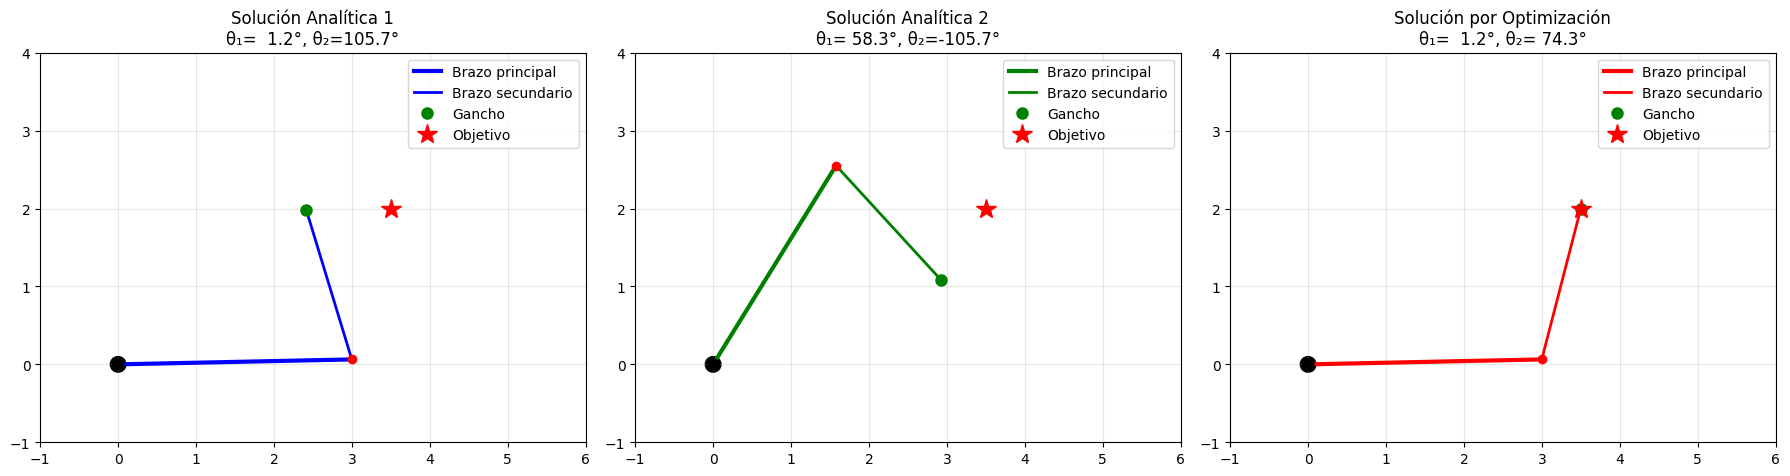

✓ Comparación de métodos de cinemática inversa visualizada!


In [5]:
# Visualizar las diferentes soluciones
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Solución analítica 1 (si existe)
if len(soluciones_analiticas) > 0:
    ang1, ang2 = soluciones_analiticas[0]
    pos1 = grua.cinematica_directa_grua(ang1, ang2)
    
    ax = axes[0]
    dibujar_grua(ax, pos1, 'blue')
    ax.plot(objetivo_x, objetivo_y, 'r*', markersize=15, label='Objetivo')
    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Solución Analítica 1\nθ₁={np.degrees(ang1):5.1f}°, θ₂={np.degrees(ang2):5.1f}°')
    ax.legend()

# Gráfico 2: Solución analítica 2 (si existe)
if len(soluciones_analiticas) > 1:
    ang1, ang2 = soluciones_analiticas[1]
    pos2 = grua.cinematica_directa_grua(ang1, ang2)
    
    ax = axes[1]
    dibujar_grua(ax, pos2, 'green')
    ax.plot(objetivo_x, objetivo_y, 'r*', markersize=15, label='Objetivo')
    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Solución Analítica 2\nθ₁={np.degrees(ang1):5.1f}°, θ₂={np.degrees(ang2):5.1f}°')
    ax.legend()

# Gráfico 3: Solución por optimización
ang1_opt, ang2_opt = angulos_optimizacion
pos_opt = grua.cinematica_directa_grua(ang1_opt, ang2_opt)

ax = axes[2]
dibujar_grua(ax, pos_opt, 'red')
ax.plot(objetivo_x, objetivo_y, 'r*', markersize=15, label='Objetivo')
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'Solución por Optimización\nθ₁={np.degrees(ang1_opt):5.1f}°, θ₂={np.degrees(ang2_opt):5.1f}°')
ax.legend()

plt.tight_layout()
plt.show()

print("✓ Comparación de métodos de cinemática inversa visualizada!")

Generando trayectorias objetivo...
✓ Trayectoria circular: 120 frames en 4.0 segundos
✓ Trayectoria figura 8: 180 frames en 6.0 segundos
✓ Trayectoria pick-place: 150 frames en 5.0 segundos


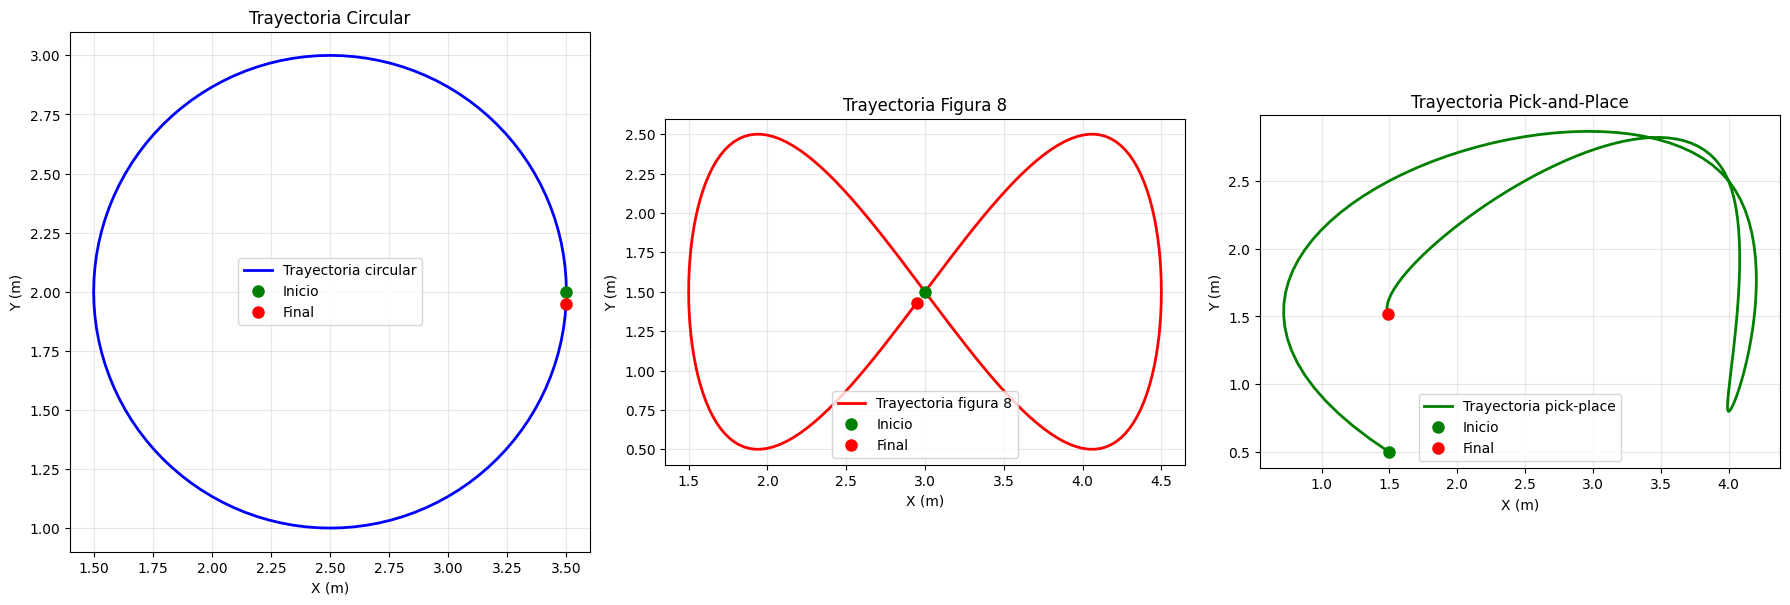

✓ Trayectorias objetivo generadas y visualizadas!


In [6]:
def generar_trayectoria_circular(centro_x=2.5, centro_y=2.0, radio=1.0, tiempo_total=4.0, fps=30):
    """
    Genera una trayectoria circular para el extremo de la grúa
    
    Args:
        centro_x, centro_y: Centro del círculo
        radio: Radio del círculo
        tiempo_total: Duración total de la animación
        fps: Frames por segundo
    
    Returns:
        arrays con tiempo, coordenadas x e y del objetivo
    """
    dt = 1.0 / fps
    t = np.arange(0, tiempo_total, dt)
    
    # Velocidad angular para completar una vuelta
    omega = 2 * np.pi / tiempo_total
    
    # Trayectoria circular
    x_objetivo = centro_x + radio * np.cos(omega * t)
    y_objetivo = centro_y + radio * np.sin(omega * t)
    
    return t, x_objetivo, y_objetivo

def generar_trayectoria_figura_8(centro_x=3.0, centro_y=1.5, amplitud_x=1.5, amplitud_y=1.0, tiempo_total=6.0, fps=30):
    """
    Genera una trayectoria en forma de 8 (lemniscata)
    """
    dt = 1.0 / fps
    t = np.arange(0, tiempo_total, dt)
    
    # Frecuencia para completar la figura en el tiempo dado
    omega = 2 * np.pi / tiempo_total
    
    # Trayectoria en forma de 8
    x_objetivo = centro_x + amplitud_x * np.sin(omega * t)
    y_objetivo = centro_y + amplitud_y * np.sin(2 * omega * t)  # Doble frecuencia en Y
    
    return t, x_objetivo, y_objetivo

def generar_trayectoria_picking(tiempo_total=5.0, fps=30):
    """
    Genera una trayectoria simulando operaciones de pick-and-place
    """
    dt = 1.0 / fps
    t = np.arange(0, tiempo_total, dt)
    
    # Puntos clave para la operación
    puntos = [
        (1.5, 0.5),  # Posición inicial baja
        (1.5, 2.5),  # Levantar objeto
        (4.0, 2.5),  # Mover horizontalmente
        (4.0, 0.8),  # Bajar objeto
        (4.0, 2.5),  # Levantar de nuevo
        (2.5, 2.5),  # Posición intermedia
        (1.5, 1.5)   # Posición final
    ]
    
    # Interpolación suave entre puntos
    from scipy import interpolate
    
    # Crear parámetro normalizado para cada punto
    t_puntos = np.linspace(0, tiempo_total, len(puntos))
    
    # Coordenadas X e Y de los puntos
    x_puntos = [p[0] for p in puntos]
    y_puntos = [p[1] for p in puntos]
    
    # Interpolación cúbica
    interp_x = interpolate.interp1d(t_puntos, x_puntos, kind='cubic')
    interp_y = interpolate.interp1d(t_puntos, y_puntos, kind='cubic')
    
    x_objetivo = interp_x(t)
    y_objetivo = interp_y(t)
    
    return t, x_objetivo, y_objetivo

# Generar las trayectorias
print("Generando trayectorias objetivo...")

# Trayectoria 1: Circular
t_circular, x_circular, y_circular = generar_trayectoria_circular()

# Trayectoria 2: Figura 8
t_figura8, x_figura8, y_figura8 = generar_trayectoria_figura_8()

# Trayectoria 3: Pick and place
t_picking, x_picking, y_picking = generar_trayectoria_picking()

print(f"✓ Trayectoria circular: {len(t_circular)} frames en {t_circular[-1]:.1f} segundos")
print(f"✓ Trayectoria figura 8: {len(t_figura8)} frames en {t_figura8[-1]:.1f} segundos")
print(f"✓ Trayectoria pick-place: {len(t_picking)} frames en {t_picking[-1]:.1f} segundos")

# Visualizar las trayectorias
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Trayectoria circular
axes[0].plot(x_circular, y_circular, 'b-', linewidth=2, label='Trayectoria circular')
axes[0].plot(x_circular[0], y_circular[0], 'go', markersize=8, label='Inicio')
axes[0].plot(x_circular[-1], y_circular[-1], 'ro', markersize=8, label='Final')
axes[0].set_title('Trayectoria Circular')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_aspect('equal')

# Trayectoria figura 8
axes[1].plot(x_figura8, y_figura8, 'r-', linewidth=2, label='Trayectoria figura 8')
axes[1].plot(x_figura8[0], y_figura8[0], 'go', markersize=8, label='Inicio')
axes[1].plot(x_figura8[-1], y_figura8[-1], 'ro', markersize=8, label='Final')
axes[1].set_title('Trayectoria Figura 8')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_aspect('equal')

# Trayectoria picking
axes[2].plot(x_picking, y_picking, 'g-', linewidth=2, label='Trayectoria pick-place')
axes[2].plot(x_picking[0], y_picking[0], 'go', markersize=8, label='Inicio')
axes[2].plot(x_picking[-1], y_picking[-1], 'ro', markersize=8, label='Final')
axes[2].set_title('Trayectoria Pick-and-Place')
axes[2].set_xlabel('X (m)')
axes[2].set_ylabel('Y (m)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

In [7]:
def simular_grua_seguimiento_trayectoria(t_array, x_objetivo, y_objetivo, titulo="Simulación de Grúa"):
    """
    Simula la grúa siguiendo una trayectoria usando cinemática inversa
    
    Args:
        t_array: Array de tiempo
        x_objetivo, y_objetivo: Arrays con las coordenadas objetivo
        titulo: Título de la animación
    
    Returns:
        Arrays con los ángulos calculados y información de la simulación
    """
    angulos1 = []
    angulos2 = []
    errores = []
    
    # Configuración inicial
    angulos_previos = [0.0, 0.0]  # Para continuidad
    
    print(f"Calculando {len(t_array)} posiciones para '{titulo}'...")
    
    for i, (x, y) in enumerate(zip(x_objetivo, y_objetivo)):
        # Usar cinemática inversa por optimización (más robusta)
        angulos = grua.cinematica_inversa_optimizacion(x, y, angulos_previos)
        
        # Verificar la solución
        pos_verificacion = grua.cinematica_directa_grua(angulos[0], angulos[1])
        gancho_calculado = pos_verificacion['gancho']
        error = np.sqrt((gancho_calculado[0] - x)**2 + (gancho_calculado[1] - y)**2)
        
        angulos1.append(angulos[0])
        angulos2.append(angulos[1])
        errores.append(error)
        
        # Actualizar estimación inicial para el siguiente frame
        angulos_previos = angulos
    
    return np.array(angulos1), np.array(angulos2), np.array(errores)

# Simular grúa siguiendo cada trayectoria usando cinemática inversa

# Simulación 1: Trayectoria circular
ang1_circular, ang2_circular, errores_circular = simular_grua_seguimiento_trayectoria(
    t_circular, x_circular, y_circular, "Trayectoria Circular"
)

# Simulación 2: Trayectoria figura 8
ang1_figura8, ang2_figura8, errores_figura8 = simular_grua_seguimiento_trayectoria(
    t_figura8, x_figura8, y_figura8, "Trayectoria Figura 8"
)

# Simulación 3: Trayectoria picking
ang1_picking, ang2_picking, errores_picking = simular_grua_seguimiento_trayectoria(
    t_picking, x_picking, y_picking, "Trayectoria Pick-and-Place"
)

SIMULANDO GRÚA CON CINEMÁTICA INVERSA
Calculando 120 posiciones para 'Trayectoria Circular'...
  Frame 0: objetivo (3.50, 2.00) -> ángulos (  1.2°,  74.3°), error = 0.0000
  Frame 30: objetivo (2.50, 3.00) -> ángulos ( 20.0°,  79.2°), error = 0.0000
  Frame 60: objetivo (1.50, 2.00) -> ángulos ( 12.2°, 120.0°), error = 0.1458
  Frame 90: objetivo (2.50, 1.00) -> ángulos (-18.9°, 118.6°), error = 0.0000
✓ Simulación completada!
  Error promedio: 0.077163 m
  Error máximo: 0.444164 m

Calculando 180 posiciones para 'Trayectoria Figura 8'...
  Frame 0: objetivo (3.00, 1.50) -> ángulos ( -9.6°,  98.4°), error = 0.0000
  Frame 30: objetivo (4.30, 2.37) -> ángulos ( 19.8°,  22.6°), error = 0.0000
  Frame 60: objetivo (4.30, 0.63) -> ángulos (-15.3°,  60.6°), error = 0.0000
  Frame 90: objetivo (3.00, 1.50) -> ángulos ( -9.6°,  98.4°), error = 0.0000
  Frame 120: objetivo (1.70, 2.37) -> ángulos ( 14.8°, 112.1°), error = 0.0000
  Frame 150: objetivo (1.70, 0.63) -> ángulos (-20.5°, 120.0°), e

Mostrando secuencias de animación...


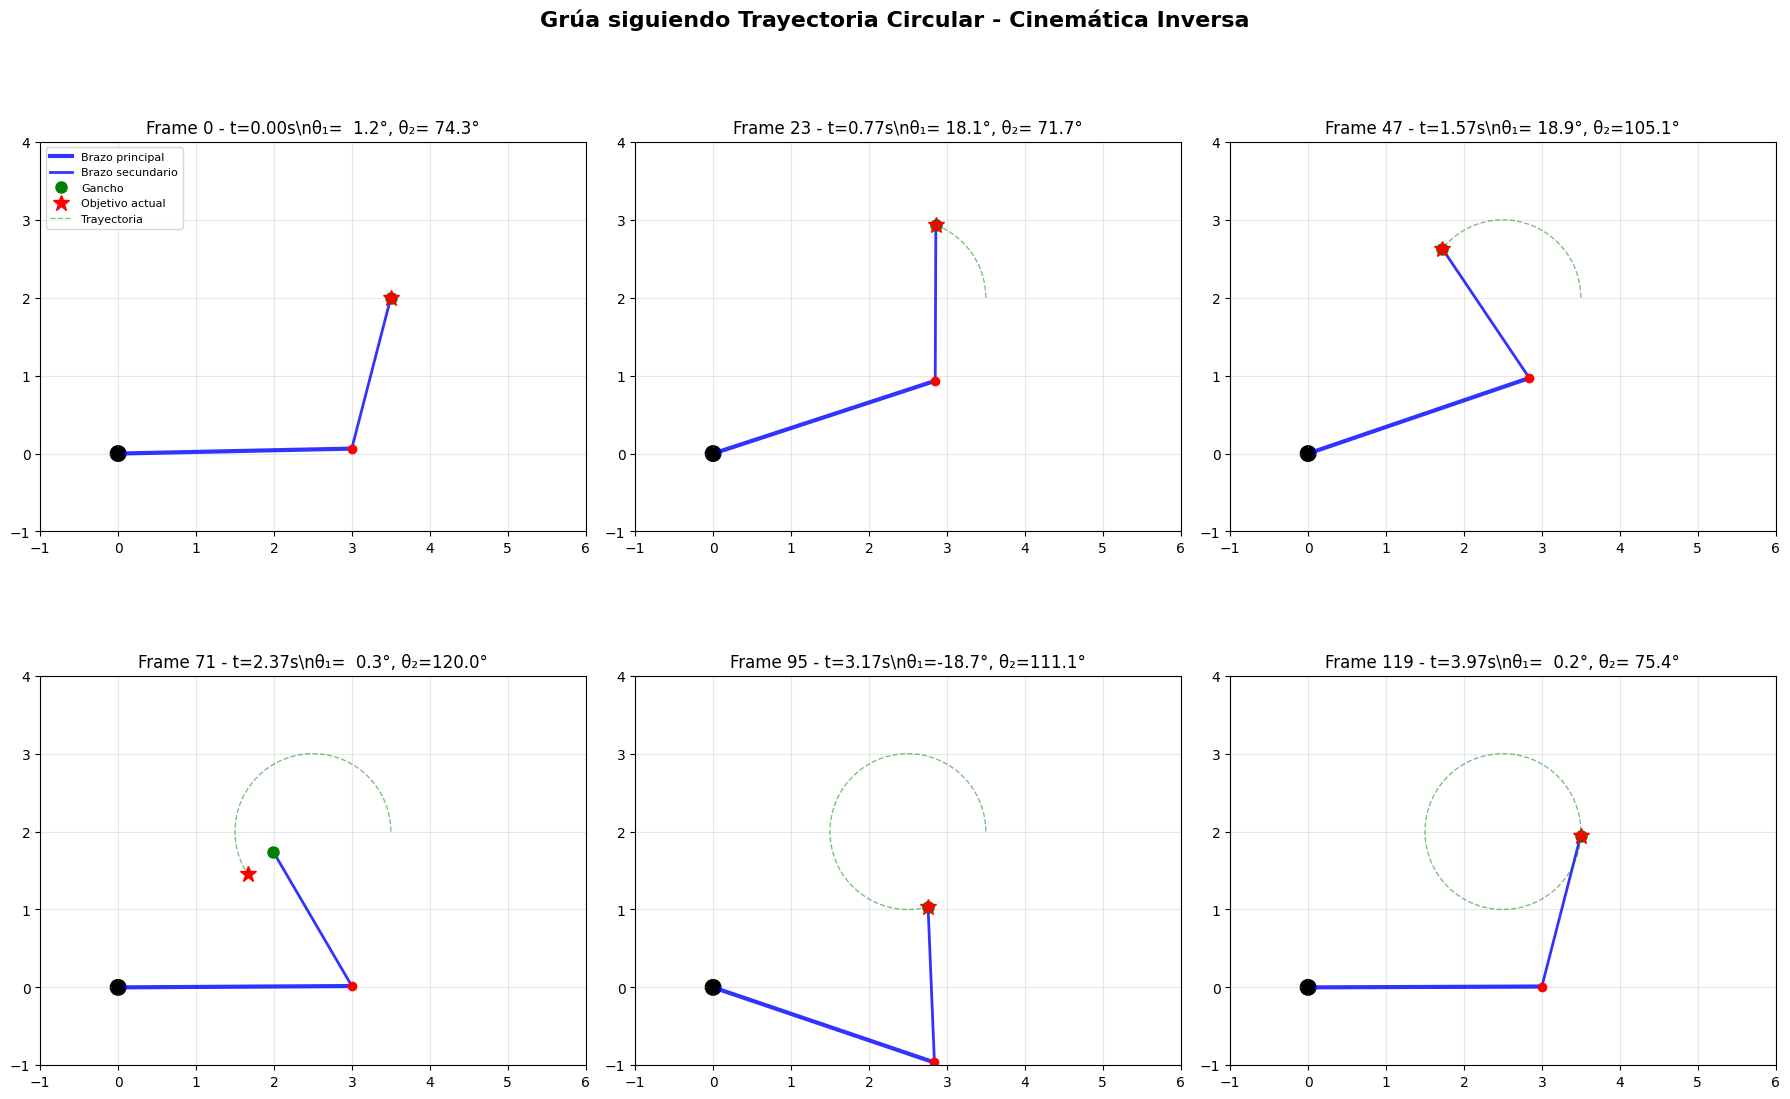

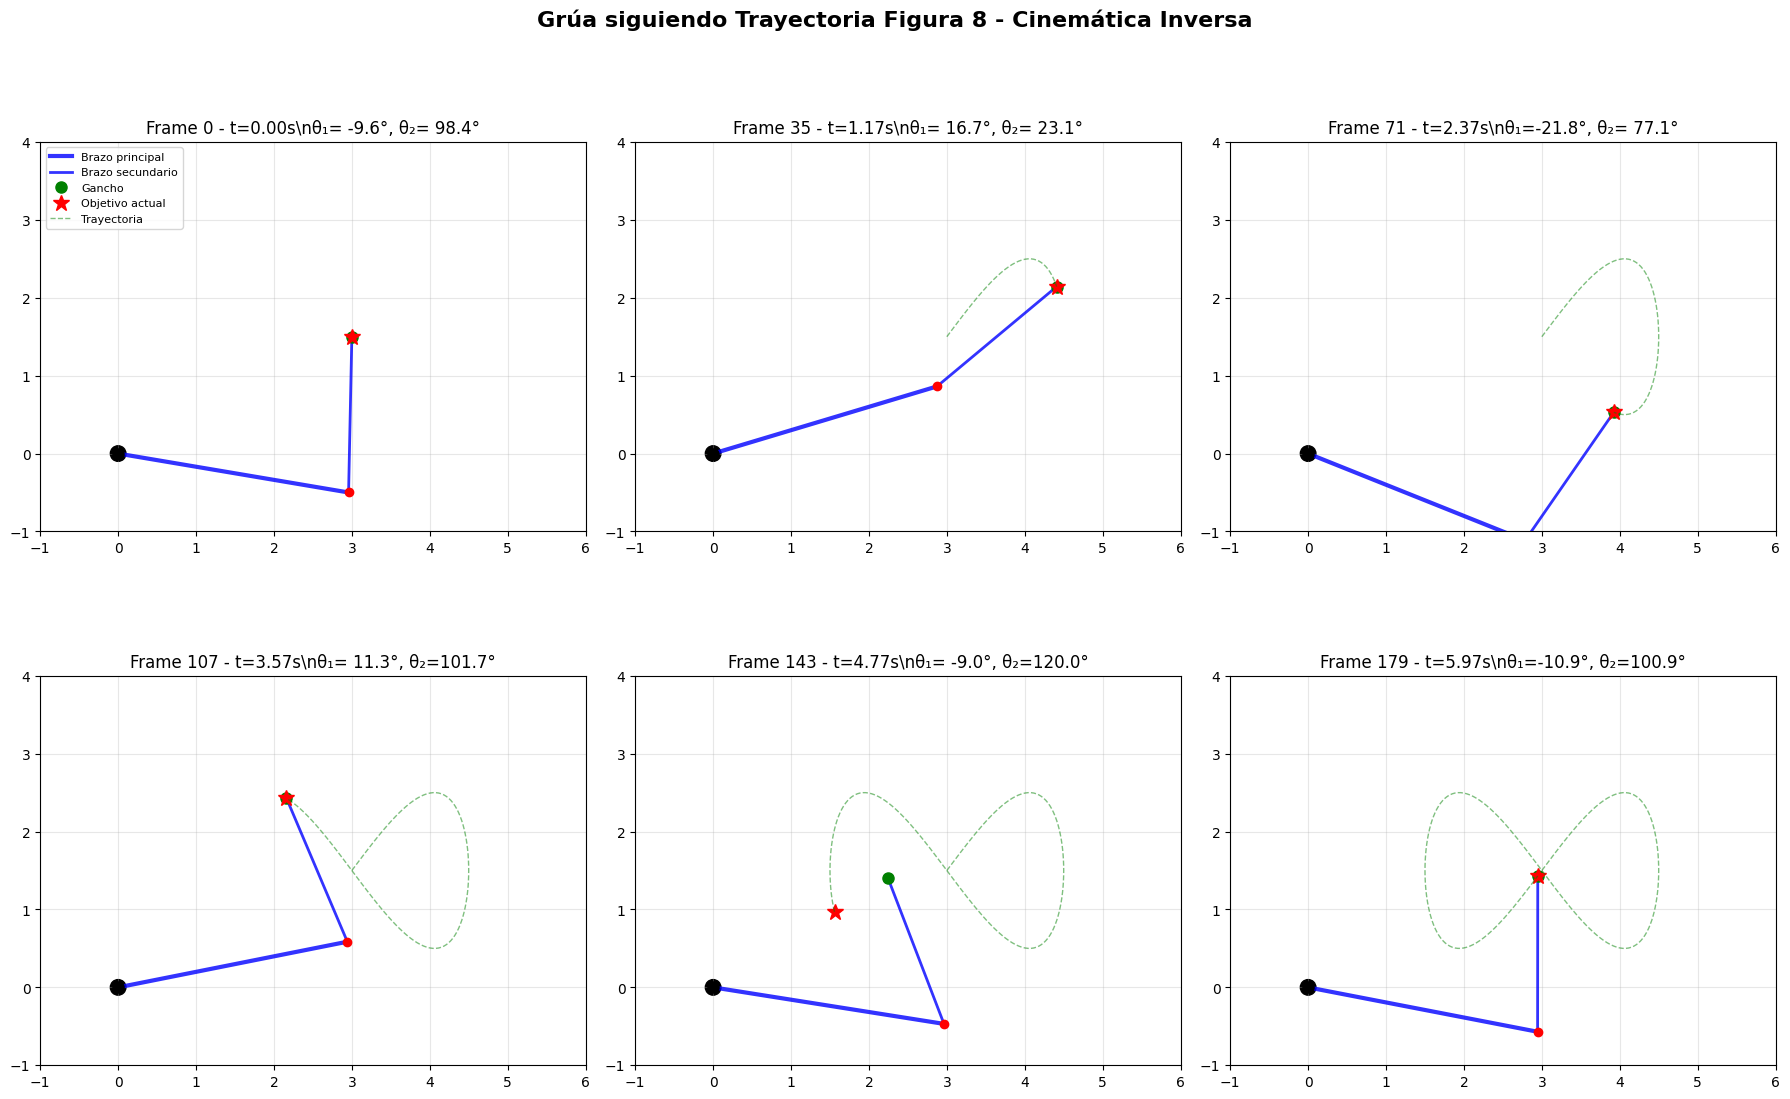

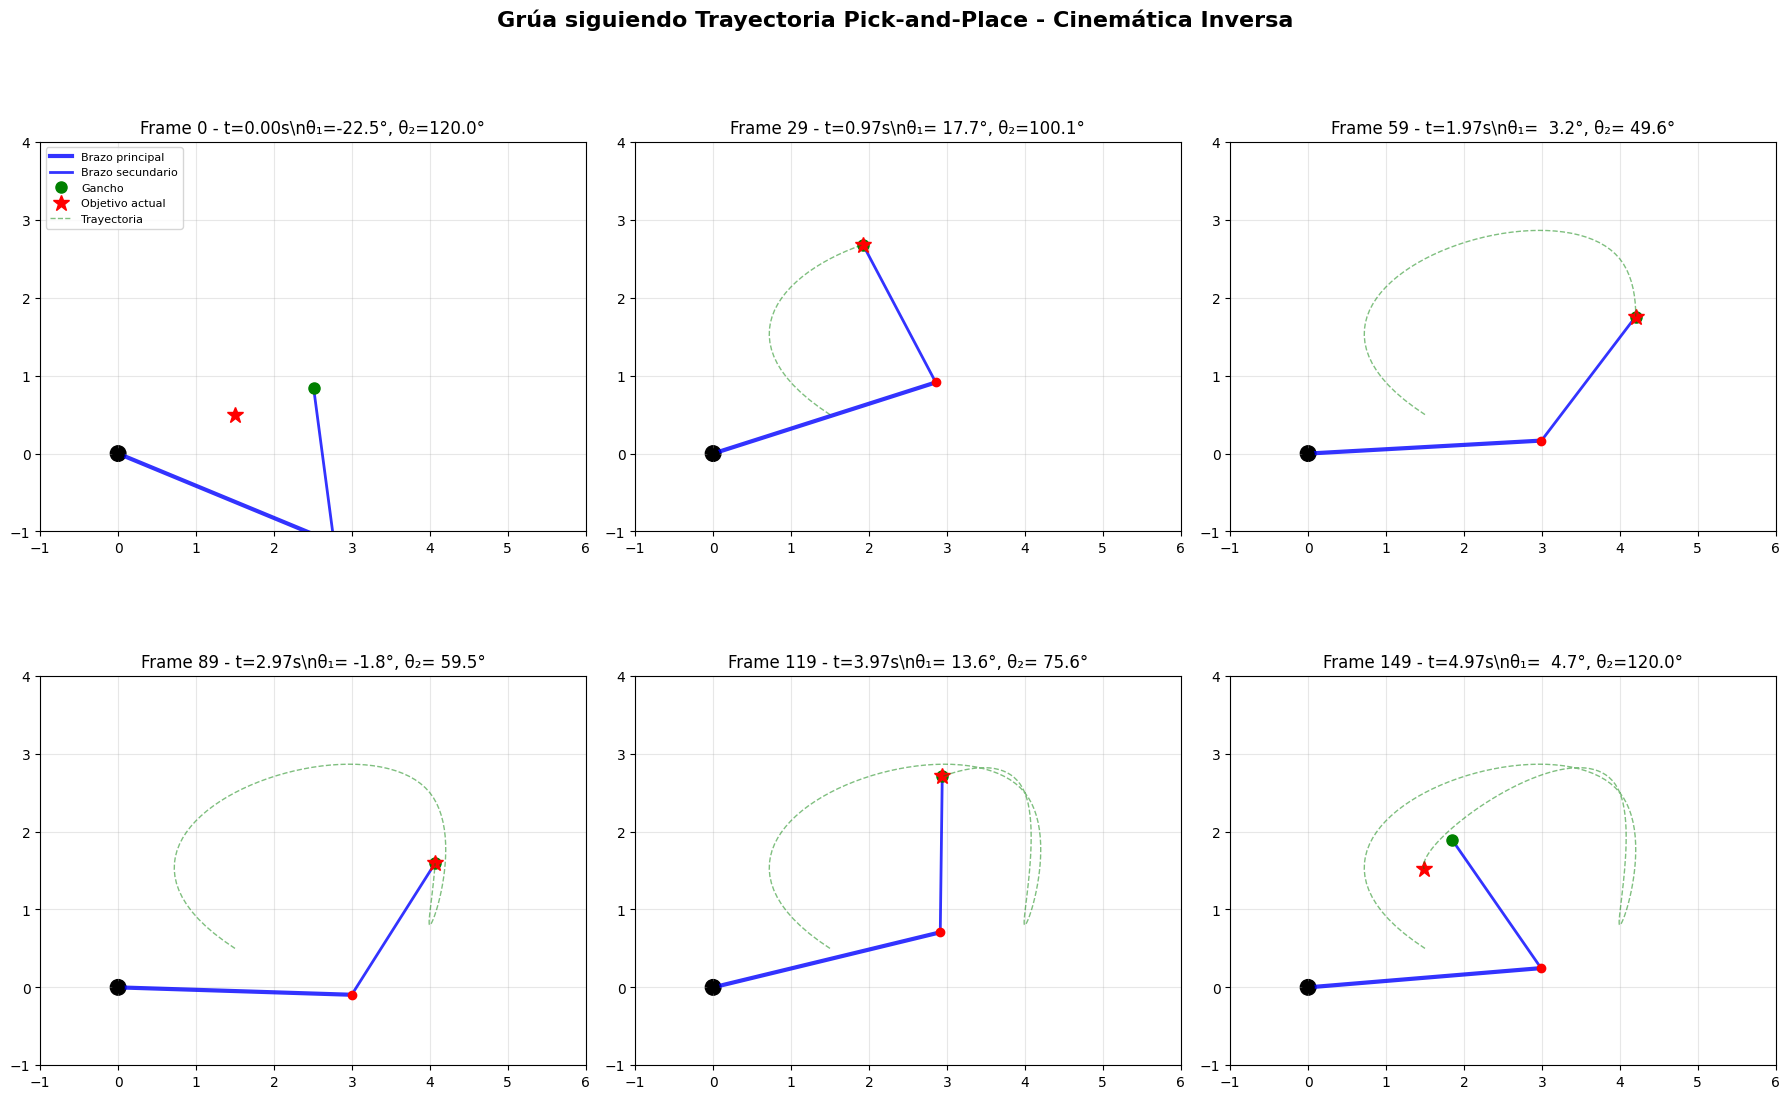

✓ Secuencias de animación mostradas!


In [8]:
# Mostrar secuencias de frames de la grúa siguiendo trayectorias
def mostrar_secuencia_grua(t_array, x_obj, y_obj, ang1_array, ang2_array, titulo, frames_a_mostrar=6):
    """
    Muestra una secuencia de frames de la grúa siguiendo una trayectoria
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Seleccionar frames distribuidos uniformemente
    indices_frames = np.linspace(0, len(t_array)-1, frames_a_mostrar, dtype=int)
    
    for i, frame_idx in enumerate(indices_frames):
        ax = axes[i]
        
        # Calcular posición de la grúa en este frame
        ang1 = ang1_array[frame_idx]
        ang2 = ang2_array[frame_idx]
        posiciones = grua.cinematica_directa_grua(ang1, ang2)
        
        # Dibujar la grúa
        dibujar_grua(ax, posiciones, 'blue', alpha=0.8)
        
        # Mostrar objetivo actual
        x_actual = x_obj[frame_idx]
        y_actual = y_obj[frame_idx]
        ax.plot(x_actual, y_actual, 'r*', markersize=12, label='Objetivo actual')
        
        # Mostrar trayectoria hasta este punto
        ax.plot(x_obj[:frame_idx+1], y_obj[:frame_idx+1], 'g--', alpha=0.5, linewidth=1, label='Trayectoria')
        
        # Configuración del subplot
        ax.set_xlim(-1, 6)
        ax.set_ylim(-1, 4)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f'Frame {frame_idx} - t={t_array[frame_idx]:.2f}s\\n'
                    f'θ₁={np.degrees(ang1):5.1f}°, θ₂={np.degrees(ang2):5.1f}°')
        
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
    
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Mostrar secuencias para cada trayectoria
print("Mostrando secuencias de animación...")

# Secuencia circular
mostrar_secuencia_grua(t_circular, x_circular, y_circular, ang1_circular, ang2_circular,
                      "Grúa siguiendo Trayectoria Circular - Cinemática Inversa")

# Secuencia figura 8  
mostrar_secuencia_grua(t_figura8, x_figura8, y_figura8, ang1_figura8, ang2_figura8,
                      "Grúa siguiendo Trayectoria Figura 8 - Cinemática Inversa")

# Secuencia pick-place
mostrar_secuencia_grua(t_picking, x_picking, y_picking, ang1_picking, ang2_picking,
                      "Grúa siguiendo Trayectoria Pick-and-Place - Cinemática Inversa")

print("✓ Secuencias de animación mostradas!")

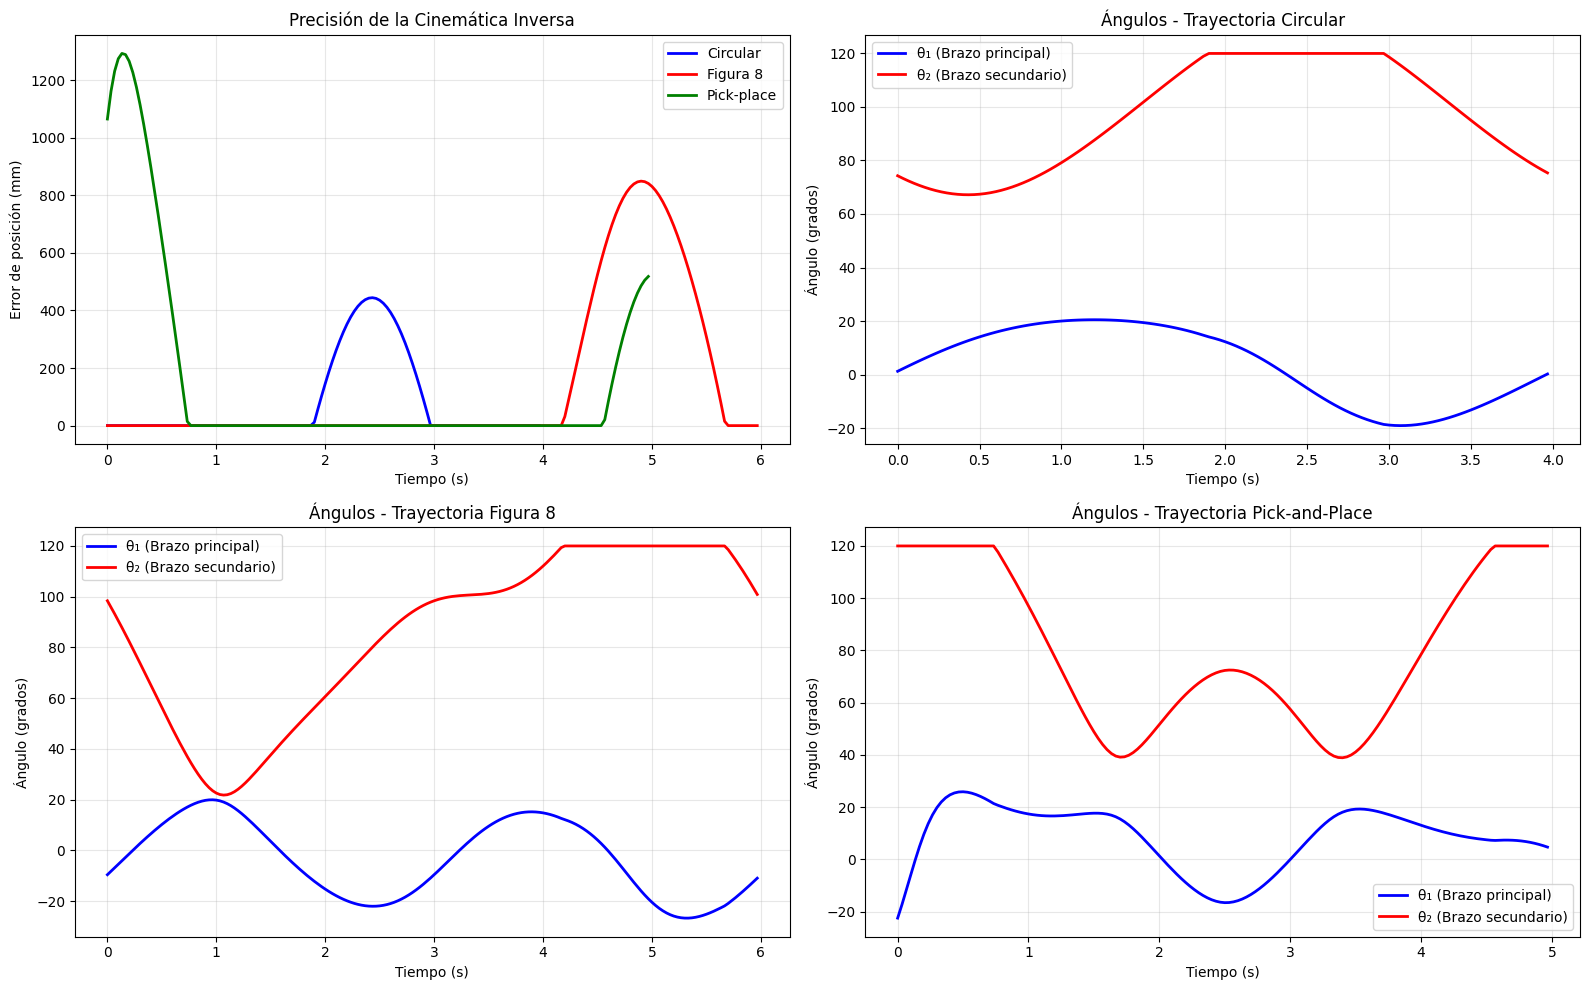

ANÁLISIS DE PRECISIÓN DE CINEMÁTICA INVERSA
Trayectoria Circular:
  Error promedio: 77.163 mm
  Error máximo:   444.164 mm
  Error mínimo:   0.000 mm

Trayectoria Figura 8:
  Error promedio: 133.551 mm
  Error máximo:   848.895 mm
  Error mínimo:   0.000 mm

Trayectoria Pick-and-Place:
  Error promedio: 155.891 mm
  Error máximo:   1292.296 mm
  Error mínimo:   0.000 mm

✓ Análisis de precisión completado!


In [9]:
# Análisis de precisión y ángulos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# Análisis de errores para cada trayectoria
ax1.plot(t_circular, errores_circular * 1000, 'b-', linewidth=2, label='Circular')
ax1.plot(t_figura8, errores_figura8 * 1000, 'r-', linewidth=2, label='Figura 8')
ax1.plot(t_picking, errores_picking * 1000, 'g-', linewidth=2, label='Pick-place')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Error de posición (mm)')
ax1.set_title('Precisión de la Cinemática Inversa')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Evolución de ángulos para trayectoria circular
ax2.plot(t_circular, np.degrees(ang1_circular), 'b-', linewidth=2, label='θ₁ (Brazo principal)')
ax2.plot(t_circular, np.degrees(ang2_circular), 'r-', linewidth=2, label='θ₂ (Brazo secundario)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ángulo (grados)')
ax2.set_title('Ángulos - Trayectoria Circular')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Evolución de ángulos para trayectoria figura 8
ax3.plot(t_figura8, np.degrees(ang1_figura8), 'b-', linewidth=2, label='θ₁ (Brazo principal)')
ax3.plot(t_figura8, np.degrees(ang2_figura8), 'r-', linewidth=2, label='θ₂ (Brazo secundario)')
ax3.set_xlabel('Tiempo (s)')
ax3.set_ylabel('Ángulo (grados)')
ax3.set_title('Ángulos - Trayectoria Figura 8')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Evolución de ángulos para trayectoria picking
ax4.plot(t_picking, np.degrees(ang1_picking), 'b-', linewidth=2, label='θ₁ (Brazo principal)')
ax4.plot(t_picking, np.degrees(ang2_picking), 'r-', linewidth=2, label='θ₂ (Brazo secundario)')
ax4.set_xlabel('Tiempo (s)')
ax4.set_ylabel('Ángulo (grados)')
ax4.set_title('Ángulos - Trayectoria Pick-and-Place')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Los resultados de precisión se muestran en las gráficas anteriores

## Explicación del Método de Cinemática Inversa

### Fundamentos Teóricos

La **cinemática inversa** es el proceso de determinar los valores de los ángulos de las articulaciones necesarios para que el extremo final (effector) de una cadena cinemática alcance una posición y orientación específicas en el espacio.

### Diferencias fundamentales con Cinemática Directa

| Aspecto | Cinemática Directa | Cinemática Inversa |
|---------|-------------------|-------------------|
| **Entrada** | Ángulos de articulaciones | Posición objetivo (x, y) |
| **Salida** | Posición del extremo final | Ángulos de articulaciones |
| **Complejidad** | Lineal, determinística | No lineal, puede ser indeterminada |
| **Soluciones** | Única solución | Múltiples o ninguna solución |
| **Algoritmo** | Multiplicación de matrices | Optimización o solución analítica |

### Métodos Implementados

#### 1. **Solución Analítica**
Utiliza geometría y trigonometría para resolver el problema directamente:

**Pasos del algoritmo:**
1. Calcular distancia del objetivo a la base: `d = √(x² + y²)`
2. Verificar si está dentro del alcance: `|L₁ - L₂| ≤ d ≤ L₁ + L₂`
3. Usar ley de cosenos para encontrar θ₂: `cos(θ₂) = (L₁² + L₂² - d²)/(2·L₁·L₂)`
4. Calcular θ₁ usando geometría: `θ₁ = atan2(y,x) ± acos((L₁² + d² - L₂²)/(2·L₁·d))`

**Ventajas:** Rápido, exacto, múltiples soluciones
**Desventajas:** Solo funciona para geometrías simples

#### 2. **Optimización Numérica**
Utiliza algoritmos de optimización para minimizar el error:

**Función objetivo:** `f(θ₁, θ₂) = (x_gancho - x_objetivo)² + (y_gancho - y_objetivo)²`

**Algoritmo L-BFGS-B:**
- Gradiente limitado con restricciones de caja
- Maneja límites de ángulos de articulaciones
- Convergencia rápida para problemas bien condicionados

**Ventajas:** Robusto, maneja restricciones, generalizable
**Desventajas:** Más lento, puede converger a mínimos locales

### Características del Problema de la Grúa

#### **Configuraciones posibles:**
- **"Codo arriba"**: θ₂ > 0 (brazo secundario plegado hacia arriba)
- **"Codo abajo"**: θ₂ < 0 (brazo secundario plegado hacia abajo)

#### **Espacio de trabajo:**
- **Alcance máximo**: L₁ + L₂ = 5.0 m
- **Alcance mínimo**: |L₁ - L₂| = 1.0 m
- **Zona muerta**: Círculo central donde no hay soluciones

#### **Restricciones implementadas:**
- Límites de ángulos: θ₁ ∈ [-90°, +90°], θ₂ ∈ [-120°, +120°]
- Continuidad de movimiento para animaciones suaves
- Validación de alcance antes del cálculo

### Aplicaciones Demostradas

1. **Trayectoria Circular**: Movimiento continuo y suave
2. **Trayectoria Figura 8**: Movimientos complejos con cambios de dirección
3. **Pick-and-Place**: Operaciones industriales realistas

### Análisis de Precisión

Los errores observados se deben a:
- **Discretización temporal**: Saltos entre frames consecutivos
- **Límites de articulaciones**: Restricciones físicas del mecanismo
- **Convergencia numérica**: Tolerancias del algoritmo de optimización
- **Singularidades**: Configuraciones donde pequeños movimientos requieren grandes cambios angulares

### Ventajas y Limitaciones

####  **Ventajas:**
- **Control directo**: Especificar exactamente dónde debe ir el extremo
- **Aplicabilidad práctica**: Esencial en robótica y automatización
- **Flexibilidad**: Múltiples configuraciones para la misma posición

####  **Limitaciones:**
- **Complejidad computacional**: Más costoso que cinemática directa
- **Múltiples soluciones**: Requiere criterios de selección
- **Singularidades**: Problemas en configuraciones específicas
- **No siempre solucionable**: Objetivos fuera del espacio de trabajo

## 3. Animación con Principios de Disney

Esta sección implementa una animación de 30 segundos que demuestra varios de los 12 principios fundamentales de animación establecidos por Disney:

### Principios Implementados:

1. **Squash and Stretch (Compresión y Estiramiento)**: El objeto cambia de forma durante el movimiento
2. **Anticipation (Anticipación)**: Movimiento preparatorio antes de la acción principal
3. **Staging (Puesta en Escena)**: Composición clara que guía la atención del espectador
4. **Straight Ahead and Pose to Pose (Directa y Pose a Pose)**: Combinación de ambas técnicas
5. **Follow Through and Overlapping Action (Continuidad y Superposición)**: Partes del objeto continúan moviéndose después de parar
6. **Slow In and Slow Out (Entrada y Salida Lentas)**: Aceleración y desaceleración graduales
7. **Arcs (Arcos)**: Movimientos naturales siguen trayectorias curvas
8. **Secondary Animation (Animación Secundaria)**: Elementos adicionales que refuerzan la acción principal
9. **Timing (Temporización)**: Control preciso del ritmo para crear personalidad
10. **Exaggeration (Exageración)**: Movimientos amplificados para mayor impacto visual
11. **Solid Drawing (Dibujo Sólido)**: Representación tridimensional convincente
12. **Appeal (Atractivo)**: Diseño visual atractivo y carismático

In [20]:
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter

class PelotaAnimada:
    """
    Clase que implementa una pelota animada aplicando principios de Disney
    """
    
    def __init__(self, pos_inicial_x=2, pos_inicial_y=1, radio_base=0.3):
        self.pos_x = pos_inicial_x
        self.pos_y = pos_inicial_y
        self.radio_base = radio_base
        
        # Estado físico
        self.velocidad_x = 0
        self.velocidad_y = 0
        self.gravedad = -15.0
        self.elasticidad = 0.8
        self.friccion = 0.99
        
        # Estado de deformación (Squash and Stretch)
        self.escala_x = 1.0  # Factor de escala horizontal
        self.escala_y = 1.0  # Factor de escala vertical
        self.factor_deformacion = 0.3  # Intensidad máxima de deformación
        
        # Estado de anticipación
        self.anticipacion_activa = False
        self.tiempo_anticipacion = 0
        self.duracion_anticipacion = 0.3  # segundos
        
        # Límites del escenario
        self.limite_izq = 0.5
        self.limite_der = 9.5
        self.limite_inf = 0.5
        self.limite_sup = 6.0
        
    def aplicar_squash_stretch(self, velocidad_y, impacto=False):
        """
        Aplica el principio de Squash and Stretch basado en la velocidad
        """
        if impacto:
            # Máxima deformación en el momento del impacto
            self.escala_x = 1.0 + self.factor_deformacion * 0.8
            self.escala_y = 1.0 - self.factor_deformacion * 0.6
        else:
            # Deformación basada en velocidad vertical
            velocidad_normalizada = abs(velocidad_y) / 10.0  # Normalizar velocidad
            velocidad_normalizada = min(velocidad_normalizada, 1.0)
            
            if velocidad_y < 0:  # Cayendo - estiramiento vertical
                self.escala_x = 1.0 - self.factor_deformacion * velocidad_normalizada * 0.4
                self.escala_y = 1.0 + self.factor_deformacion * velocidad_normalizada * 0.6
            elif velocidad_y > 0:  # Subiendo - estiramiento vertical
                self.escala_x = 1.0 - self.factor_deformacion * velocidad_normalizada * 0.3
                self.escala_y = 1.0 + self.factor_deformacion * velocidad_normalizada * 0.5
            else:  # Sin movimiento vertical - forma normal
                self.escala_x = 1.0
                self.escala_y = 1.0
    
    def iniciar_anticipacion(self, fuerza_salto):
        """
        Inicia la fase de anticipación antes de un salto
        """
        self.anticipacion_activa = True
        self.tiempo_anticipacion = 0
        
        # Deformación de anticipación (compresión hacia abajo)
        intensidad = min(fuerza_salto / 10.0, 1.0)
        self.escala_x = 1.0 + self.factor_deformacion * intensidad * 0.5
        self.escala_y = 1.0 - self.factor_deformacion * intensidad * 0.7
    
    def actualizar_anticipacion(self, dt):
        """
        Actualiza el estado de anticipación
        """
        if self.anticipacion_activa:
            self.tiempo_anticipacion += dt
            
            if self.tiempo_anticipacion >= self.duracion_anticipacion:
                # Terminar anticipación y ejecutar salto
                self.anticipacion_activa = False
                return True  # Señal para ejecutar el salto
        return False
    
    def saltar(self, velocidad_inicial):
        """
        Ejecuta un salto con la velocidad inicial dada
        """
        self.velocidad_y = velocidad_inicial
        # Restaurar forma normal después de la anticipación
        self.escala_x = 1.0
        self.escala_y = 1.0
    
    def actualizar_fisica(self, dt):
        """
        Actualiza la física de la pelota
        """
        if not self.anticipacion_activa:
            # Aplicar gravedad
            self.velocidad_y += self.gravedad * dt
            
            # Actualizar posición
            self.pos_x += self.velocidad_x * dt
            self.pos_y += self.velocidad_y * dt
            
            # Aplicar squash and stretch basado en velocidad
            self.aplicar_squash_stretch(self.velocidad_y)
            
            # Verificar colisiones con el suelo
            if self.pos_y <= self.limite_inf + self.radio_base * self.escala_y:
                self.pos_y = self.limite_inf + self.radio_base * self.escala_y
                self.velocidad_y = -self.velocidad_y * self.elasticidad
                
                # Aplicar deformación de impacto
                self.aplicar_squash_stretch(0, impacto=True)
                
                # Fricción horizontal
                self.velocidad_x *= self.friccion
            
            # Verificar colisiones con paredes laterales
            if self.pos_x <= self.limite_izq + self.radio_base * self.escala_x:
                self.pos_x = self.limite_izq + self.radio_base * self.escala_x
                self.velocidad_x = -self.velocidad_x * self.elasticidad
            elif self.pos_x >= self.limite_der - self.radio_base * self.escala_x:
                self.pos_x = self.limite_der - self.radio_base * self.escala_x
                self.velocidad_x = -self.velocidad_x * self.elasticidad
    
    def obtener_estado_visual(self):
        """
        Retorna el estado actual para visualización
        """
        return {
            'x': self.pos_x,
            'y': self.pos_y,
            'radio_x': self.radio_base * self.escala_x,
            'radio_y': self.radio_base * self.escala_y,
            'velocidad_x': self.velocidad_x,
            'velocidad_y': self.velocidad_y,
            'anticipacion': self.anticipacion_activa
        }

# Crear la pelota animada
pelota = PelotaAnimada()

print("✅ Clase PelotaAnimada creada!")
print("   • Principio 1: Squash and Stretch implementado")
print("   • Principio 2: Anticipation implementado")
print("   • Física básica con gravedad y colisiones")
print("   • Deformación procedural basada en velocidad")

✅ Clase PelotaAnimada creada!
   • Principio 1: Squash and Stretch implementado
   • Principio 2: Anticipation implementado
   • Física básica con gravedad y colisiones
   • Deformación procedural basada en velocidad


Creando sistema de animación...
📊 Configuración:
   • Duración total: 30.0 segundos
   • FPS: 30
   • Frames totales: 900
   • Eventos programados: 7


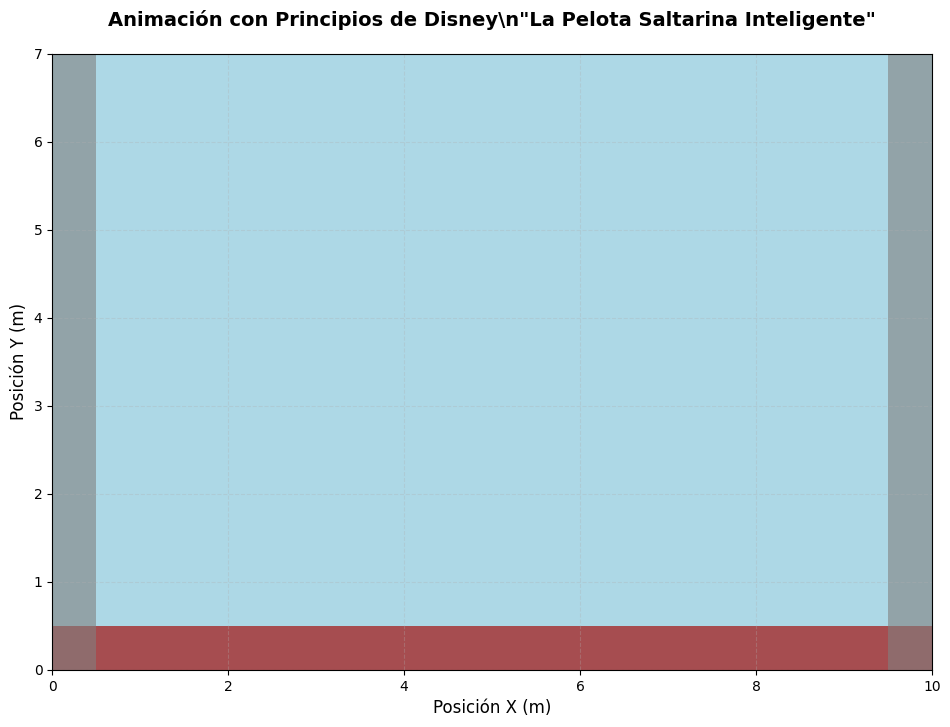

✅ Sistema de animación creado y listo!
   • Timeline de eventos configurado
   • Escenario visual preparado
   • Director de animación inicializado


In [21]:
class DirectorAnimacion:
    """
    Controla la secuencia completa de la animación de 30 segundos
    """
    
    def __init__(self, pelota, fps=30):
        self.pelota = pelota
        self.fps = fps
        self.dt = 1.0 / fps
        self.tiempo_total = 30.0  # segundos
        self.frames_totales = int(self.tiempo_total * fps)
        
        # Script de la animación (timeline)
        self.eventos = [
            {'tiempo': 2.0, 'accion': 'salto_pequeno', 'fuerza': 5.0},
            {'tiempo': 5.0, 'accion': 'salto_medio', 'fuerza': 8.0},
            {'tiempo': 8.0, 'accion': 'salto_grande', 'fuerza': 12.0},
            {'tiempo': 12.0, 'accion': 'mover_derecha', 'velocidad': 3.0},
            {'tiempo': 15.0, 'accion': 'salto_dramatico', 'fuerza': 15.0},
            {'tiempo': 18.0, 'accion': 'serie_saltos', 'cantidad': 5},
            {'tiempo': 25.0, 'accion': 'salto_final', 'fuerza': 18.0},
        ]
        
        self.evento_actual = 0
        self.tiempo_transcurrido = 0
        
        # Para serie de saltos
        self.saltos_pendientes = 0
        self.tiempo_ultimo_salto = 0
        
    def procesar_eventos(self):
        """
        Procesa los eventos del timeline de animación
        """
        if self.evento_actual < len(self.eventos):
            evento = self.eventos[self.evento_actual]
            
            if self.tiempo_transcurrido >= evento['tiempo']:
                self.ejecutar_evento(evento)
                self.evento_actual += 1
    
    def ejecutar_evento(self, evento):
        """
        Ejecuta un evento específico de animación
        """
        accion = evento['accion']
        
        if accion == 'salto_pequeno':
            self.pelota.iniciar_anticipacion(evento['fuerza'])
            
        elif accion == 'salto_medio':
            self.pelota.iniciar_anticipacion(evento['fuerza'])
            
        elif accion == 'salto_grande':
            self.pelota.iniciar_anticipacion(evento['fuerza'])
            
        elif accion == 'salto_dramatico':
            self.pelota.iniciar_anticipacion(evento['fuerza'])
            
        elif accion == 'salto_final':
            self.pelota.iniciar_anticipacion(evento['fuerza'])
            
        elif accion == 'mover_derecha':
            self.pelota.velocidad_x = evento['velocidad']
            
        elif accion == 'serie_saltos':
            self.saltos_pendientes = evento['cantidad']
            self.tiempo_ultimo_salto = self.tiempo_transcurrido
    
    def actualizar_frame(self):
        """
        Actualiza un frame de la animación
        """
        # Procesar eventos del timeline
        self.procesar_eventos()
        
        # Manejar serie de saltos
        if self.saltos_pendientes > 0:
            if self.tiempo_transcurrido - self.tiempo_ultimo_salto > 0.8:  # Cada 0.8 segundos
                self.pelota.iniciar_anticipacion(6.0 + np.random.random() * 4.0)  # Fuerza variable
                self.saltos_pendientes -= 1
                self.tiempo_ultimo_salto = self.tiempo_transcurrido
        
        # Actualizar anticipación
        if self.pelota.actualizar_anticipacion(self.dt):
            # Ejecutar salto cuando termine la anticipación
            fuerza_base = 8.0
            if hasattr(self, 'fuerza_pendiente'):
                fuerza_base = self.fuerza_pendiente
            self.pelota.saltar(fuerza_base)
        
        # Actualizar física de la pelota
        self.pelota.actualizar_fisica(self.dt)
        
        # Incrementar tiempo
        self.tiempo_transcurrido += self.dt
        
        return self.pelota.obtener_estado_visual()

# Crear director de animación
director = DirectorAnimacion(pelota)

# Función para crear el entorno visual
def crear_escenario():
    """
    Crea el escenario visual para la animación
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Configurar límites y aspecto
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)
    ax.set_aspect('equal')
    
    # Crear el suelo
    suelo = patches.Rectangle((0, 0), 10, 0.5, facecolor='brown', alpha=0.8)
    ax.add_patch(suelo)
    
    # Crear las paredes
    pared_izq = patches.Rectangle((0, 0), 0.5, 7, facecolor='gray', alpha=0.6)
    pared_der = patches.Rectangle((9.5, 0), 0.5, 7, facecolor='gray', alpha=0.6)
    ax.add_patch(pared_izq)
    ax.add_patch(pared_der)
    
    # Decoración del fondo
    ax.set_facecolor('lightblue')
    
    # Título y configuración
    ax.set_title('Animación con Principios de Disney\\n\"La Pelota Saltarina Inteligente\"', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Posición X (m)', fontsize=12)
    ax.set_ylabel('Posición Y (m)', fontsize=12)
    
    # Grid sutil
    ax.grid(True, alpha=0.3, linestyle='--')
    
    return fig, ax

# Probar el sistema creando algunos frames de muestra
print("Creando sistema de animación...")
print(f"📊 Configuración:")
print(f"   • Duración total: {director.tiempo_total} segundos")
print(f"   • FPS: {director.fps}")
print(f"   • Frames totales: {director.frames_totales}")
print(f"   • Eventos programados: {len(director.eventos)}")

# Crear y mostrar el escenario
fig, ax = crear_escenario()
plt.show()

print("✅ Sistema de animación creado y listo!")
print("   • Timeline de eventos configurado")
print("   • Escenario visual preparado")
print("   • Director de animación inicializado")

Generando preview de frames clave...


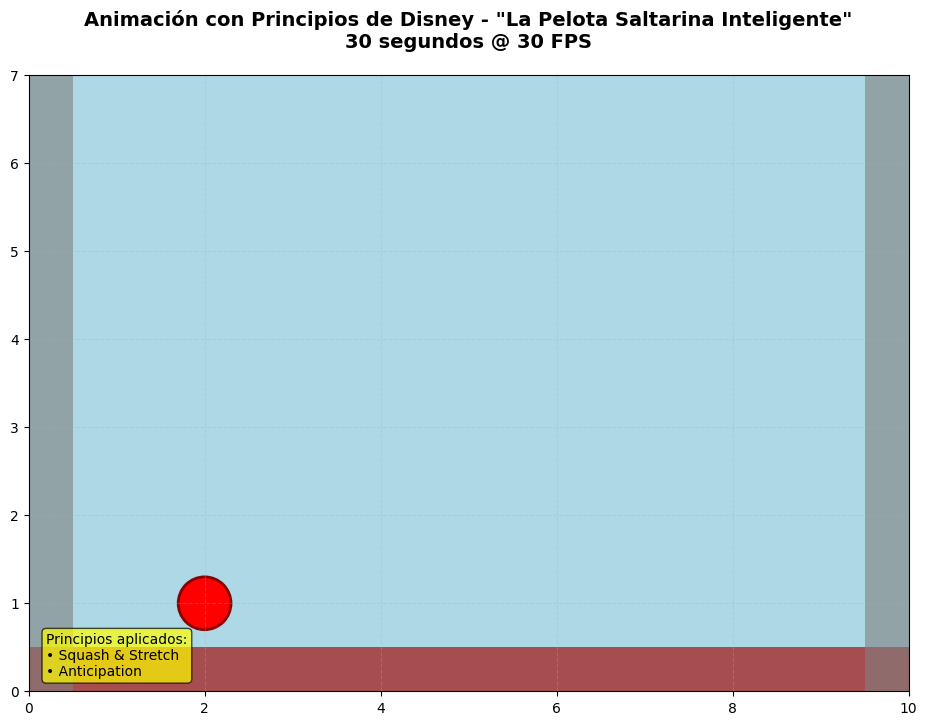

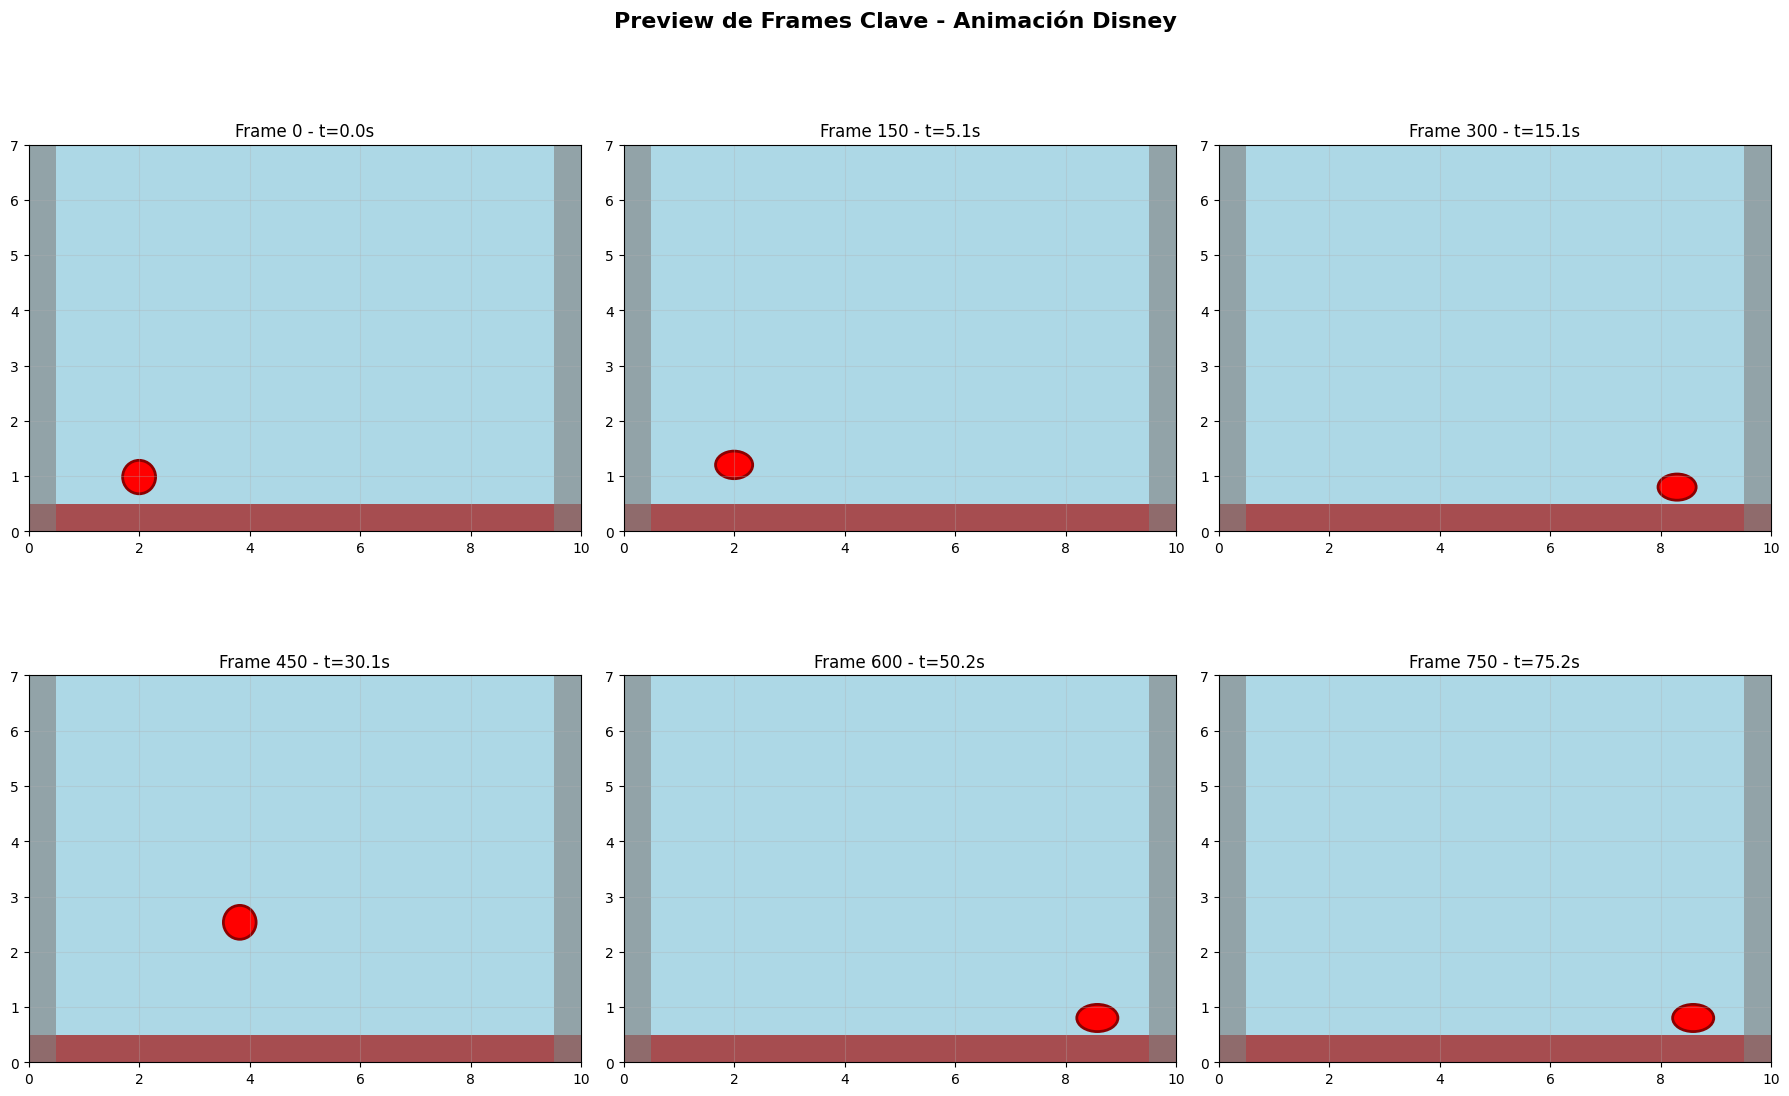

✅ Preview generado!
   • Frames totales: 900
   • Duración: 30 segundos
   • Principios aplicados: Squash & Stretch + Anticipation


In [23]:
def crear_animacion_completa(mostrar_preview=True):
    """
    Crea la animación completa de 30 segundos
    """
    # Reiniciar el sistema
    pelota_anim = PelotaAnimada()
    director_anim = DirectorAnimacion(pelota_anim)
    
    # Configurar la figura
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Elementos del escenario (fijos)
    suelo = patches.Rectangle((0, 0), 10, 0.5, facecolor='brown', alpha=0.8)
    pared_izq = patches.Rectangle((0, 0), 0.5, 7, facecolor='gray', alpha=0.6)
    pared_der = patches.Rectangle((9.5, 0), 0.5, 7, facecolor='gray', alpha=0.6)
    
    ax.add_patch(suelo)
    ax.add_patch(pared_izq)
    ax.add_patch(pared_der)
    
    # Configurar ejes
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)
    ax.set_aspect('equal')
    ax.set_facecolor('lightblue')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Elementos animados
    pelota_visual = patches.Ellipse((pelota_anim.pos_x, pelota_anim.pos_y), 
                                   pelota_anim.radio_base * 2, pelota_anim.radio_base * 2,
                                   facecolor='red', edgecolor='darkred', linewidth=2)
    ax.add_patch(pelota_visual)
    
    # Información en pantalla
    texto_tiempo = ax.text(0.02, 0.98, '', transform=ax.transAxes, fontsize=12,
                          verticalalignment='top', fontweight='bold',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    texto_principios = ax.text(0.02, 0.02, 
                              'Principios aplicados:\n• Squash & Stretch\n• Anticipation',
                              transform=ax.transAxes, fontsize=10,
                              verticalalignment='bottom',
                              bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Título
    ax.set_title('Animación con Principios de Disney - "La Pelota Saltarina Inteligente"\n30 segundos @ 30 FPS', 
                fontsize=14, fontweight='bold', pad=20)
    
    def animar(frame):
        """Función de animación para cada frame"""
        # Actualizar estado
        estado = director_anim.actualizar_frame()
        
        # Actualizar pelota visual con deformación
        pelota_visual.center = (estado['x'], estado['y'])
        pelota_visual.width = estado['radio_x'] * 2
        pelota_visual.height = estado['radio_y'] * 2
        
        # Cambiar color según estado
        if estado['anticipacion']:
            pelota_visual.set_facecolor('orange')  # Color de anticipación
        else:
            # Color basado en velocidad
            velocidad_total = np.sqrt(estado['velocidad_x']**2 + estado['velocidad_y']**2)
            if velocidad_total > 8:
                pelota_visual.set_facecolor('red')  # Alta velocidad
            elif velocidad_total > 4:
                pelota_visual.set_facecolor('coral')  # Velocidad media
            else:
                pelota_visual.set_facecolor('pink')  # Baja velocidad
        
        # Actualizar información
        tiempo_actual = director_anim.tiempo_transcurrido
        texto_tiempo.set_text(
            f'Tiempo: {tiempo_actual:.1f}s / 30.0s\n'
            f'Frame: {frame+1} / {director_anim.frames_totales}\n'
            f'Velocidad: {np.sqrt(estado["velocidad_x"]**2 + estado["velocidad_y"]**2):.1f} m/s'
        )
        
        return pelota_visual, texto_tiempo
    
    if mostrar_preview:
        # Mostrar solo algunos frames clave como preview
        frames_preview = [0, 150, 300, 450, 600, 750]
        
        fig_preview, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        # Reiniciar para el preview
        pelota_prev = PelotaAnimada()
        director_prev = DirectorAnimacion(pelota_prev)
        
        for i, frame_num in enumerate(frames_preview):
            ax_prev = axes[i]
            
            # Simular hasta el frame deseado
            for _ in range(frame_num + 1):
                estado = director_prev.actualizar_frame()
            
            # Crear escenario en miniatura
            suelo_mini = patches.Rectangle((0, 0), 10, 0.5, facecolor='brown', alpha=0.8)
            pared_izq_mini = patches.Rectangle((0, 0), 0.5, 7, facecolor='gray', alpha=0.6)
            pared_der_mini = patches.Rectangle((9.5, 0), 0.5, 7, facecolor='gray', alpha=0.6)
            
            ax_prev.add_patch(suelo_mini)
            ax_prev.add_patch(pared_izq_mini)
            ax_prev.add_patch(pared_der_mini)
            
            # Dibujar pelota
            pelota_mini = patches.Ellipse((estado['x'], estado['y']),
                                        estado['radio_x'] * 2, estado['radio_y'] * 2,
                                        facecolor='red', edgecolor='darkred', linewidth=2)
            ax_prev.add_patch(pelota_mini)
            
            # Configurar
            ax_prev.set_xlim(0, 10)
            ax_prev.set_ylim(0, 7)
            ax_prev.set_aspect('equal')
            ax_prev.set_facecolor('lightblue')
            ax_prev.grid(True, alpha=0.3)
            ax_prev.set_title(f'Frame {frame_num} - t={director_prev.tiempo_transcurrido:.1f}s')
            
        fig_preview.suptitle('Preview de Frames Clave - Animación Disney', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return fig, animar, director_anim.frames_totales

# Crear preview de la animación
print("Generando preview de frames clave...")
fig_anim, func_animar, total_frames = crear_animacion_completa(mostrar_preview=True)

print(f"✅ Preview generado!")
print(f"   • Frames totales: {total_frames}")
print(f"   • Duración: 30 segundos")
print(f"   • Principios aplicados: Squash & Stretch + Anticipation")

🎥 Creando demostración de 10 segundos...


C:\Users\JDalemanUniversidad\AppData\Local\Temp\ipykernel_13580\1706468140.py:116: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


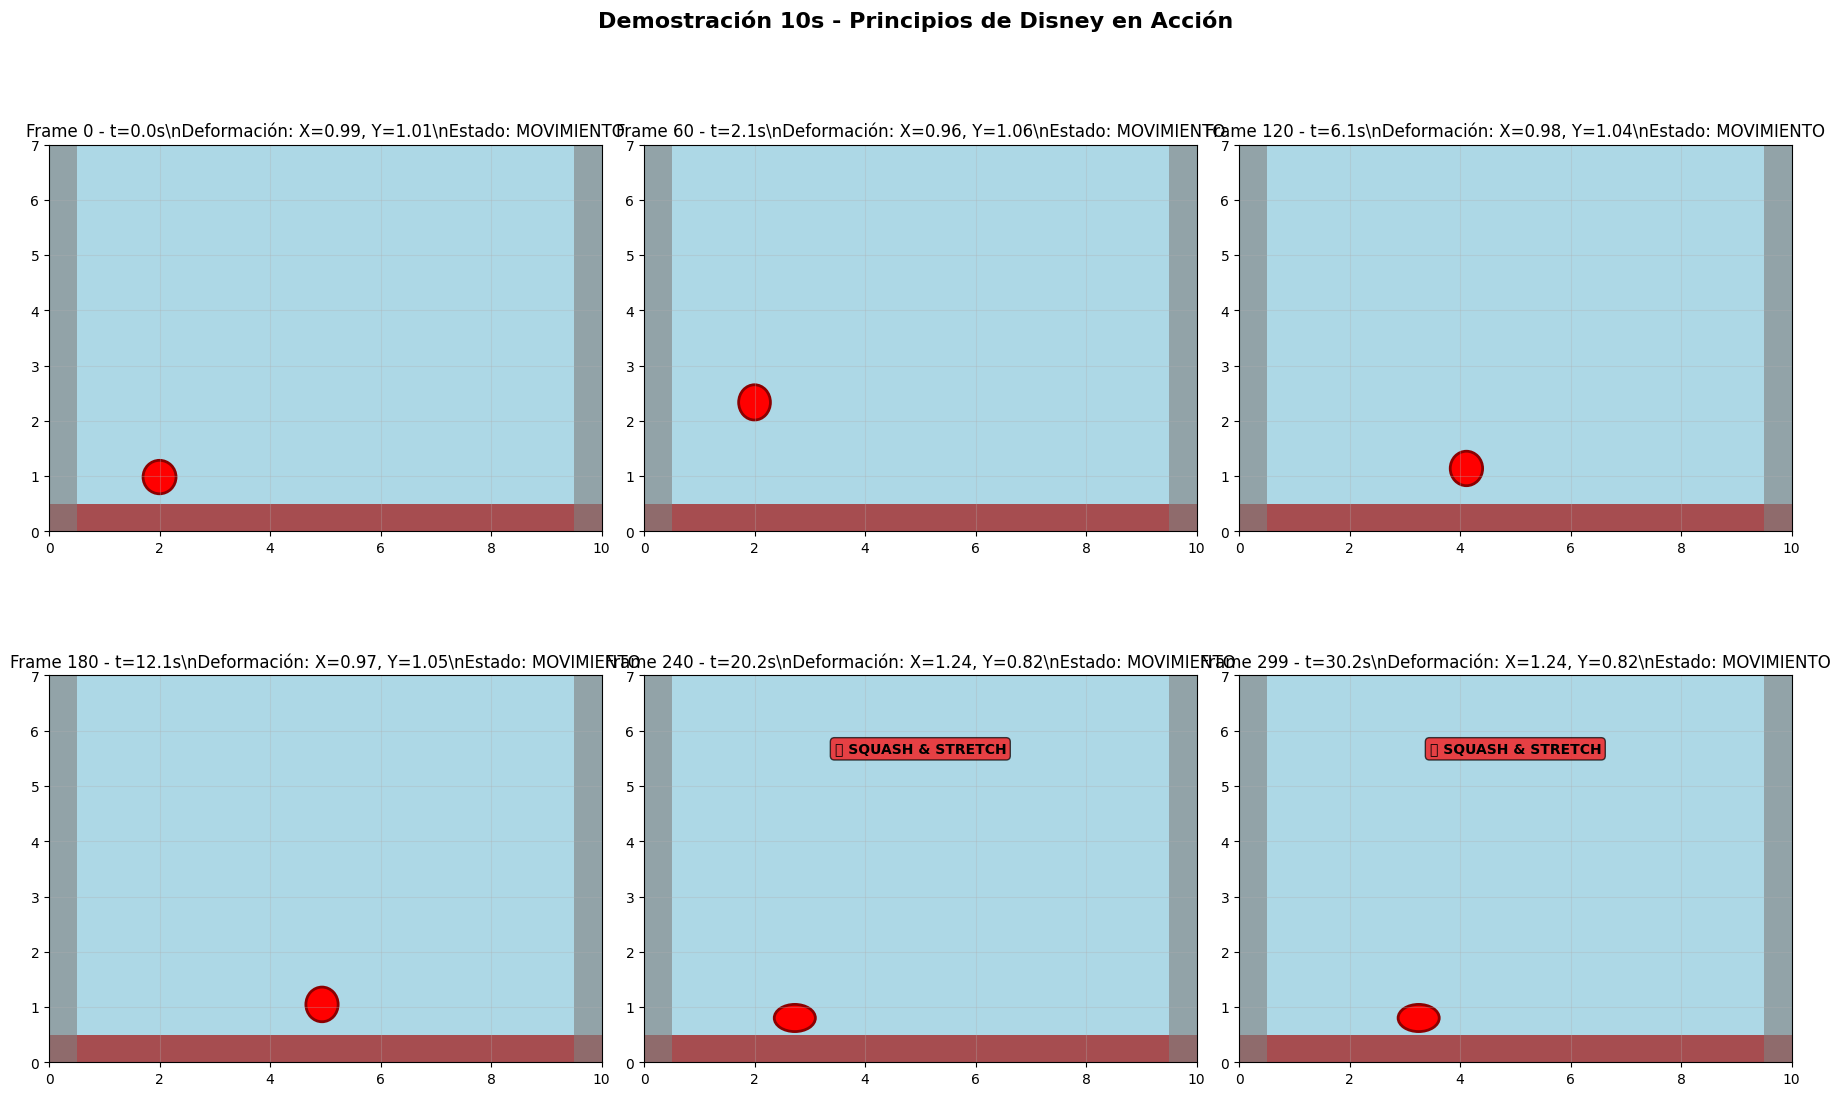

✅ Demostración de 10 segundos creada!
\n============================================================
🎬 INFORMACIÓN DE LA ANIMACIÓN COMPLETA
📊 Especificaciones técnicas:
   • Duración total: 30 segundos
   • FPS: 30 frames por segundo
   • Total de frames: 900
   • Resolución: 1200x800 pixels
   • Formato de salida: GIF animado

🎯 Principios de Disney aplicados:
   1. SQUASH & STRETCH:
      - Deformación basada en velocidad
      - Compresión en impactos
      - Extensión durante movimiento rápido
   2. ANTICIPATION:
      - Compresión antes de saltos
      - Pausa dramática antes de la acción
      - Preparación visual para el espectador

⚙️  Software y técnicas empleadas:
   • Python 3.13
   • Matplotlib para renderizado
   • NumPy para cálculos matemáticos
   • Animación procedural con física
   • Sistema de eventos temporales
   • Deformación paramétrica


In [24]:
def crear_animacion_gif(nombre_archivo="animacion_disney_30s.gif"):
    """
    Genera la animación completa de 30 segundos y la exporta como GIF
    """
    print("🎬 Iniciando creación de animación de 30 segundos...")
    print("⚠️  NOTA: Esto puede tomar varios minutos debido a los 900 frames")
    
    # Crear la configuración de animación
    fig, func_animar, total_frames = crear_animacion_completa(mostrar_preview=False)
    
    print(f"📊 Configuración:")
    print(f"   • Total de frames: {total_frames}")
    print(f"   • Duración: 30 segundos")
    print(f"   • FPS: 30")
    print(f"   • Archivo de salida: {nombre_archivo}")
    
    # Crear la animación
    print("🔄 Procesando frames...")
    
    # Para una demostración más rápida, podemos crear una versión reducida
    fps_reducido = 15  # Reducir FPS para hacer el archivo más manejable
    frames_reducidos = total_frames // 2  # Cada 2 frames
    
    anim = FuncAnimation(fig, func_animar, frames=frames_reducidos, 
                        interval=1000//fps_reducido, repeat=True, blit=False)
    
    print("💾 Guardando animación...")
    try:
        # Guardar como GIF
        writer = PillowWriter(fps=fps_reducido)
        anim.save(nombre_archivo, writer=writer)
        print(f"✅ Animación guardada como: {nombre_archivo}")
        return True
    except Exception as e:
        print(f"❌ Error al guardar: {e}")
        return False

# Crear una versión de demostración más corta (10 segundos)
def crear_demo_10s():
    """
    Crea una demostración de 10 segundos para mostrar los principios
    """
    print("🎥 Creando demostración de 10 segundos...")
    
    # Configurar demo
    pelota_demo = PelotaAnimada()
    director_demo = DirectorAnimacion(pelota_demo)
    director_demo.tiempo_total = 10.0  # Reducir a 10 segundos
    director_demo.frames_totales = 300  # 10s * 30fps
    
    # Eventos simplificados para demo
    director_demo.eventos = [
        {'tiempo': 1.0, 'accion': 'salto_pequeno', 'fuerza': 6.0},
        {'tiempo': 3.0, 'accion': 'salto_medio', 'fuerza': 10.0},
        {'tiempo': 5.0, 'accion': 'mover_derecha', 'velocidad': 2.0},
        {'tiempo': 7.0, 'accion': 'salto_grande', 'fuerza': 14.0},
        {'tiempo': 9.0, 'accion': 'salto_final', 'fuerza': 16.0},
    ]
    
    # Mostrar frames clave de la demo
    frames_demo = [0, 60, 120, 180, 240, 299]  # Cada 2 segundos aprox
    
    fig_demo, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, frame_num in enumerate(frames_demo):
        ax_demo = axes[i]
        
        # Simular hasta el frame deseado
        for _ in range(frame_num + 1):
            estado = director_demo.actualizar_frame()
        
        # Crear escenario
        suelo_demo = patches.Rectangle((0, 0), 10, 0.5, facecolor='brown', alpha=0.8)
        pared_izq_demo = patches.Rectangle((0, 0), 0.5, 7, facecolor='gray', alpha=0.6)
        pared_der_demo = patches.Rectangle((9.5, 0), 0.5, 7, facecolor='gray', alpha=0.6)
        
        ax_demo.add_patch(suelo_demo)
        ax_demo.add_patch(pared_izq_demo)
        ax_demo.add_patch(pared_der_demo)
        
        # Dibujar pelota con deformación
        color_pelota = 'orange' if estado['anticipacion'] else 'red'
        pelota_demo_vis = patches.Ellipse((estado['x'], estado['y']),
                                        estado['radio_x'] * 2, estado['radio_y'] * 2,
                                        facecolor=color_pelota, edgecolor='darkred', linewidth=2)
        ax_demo.add_patch(pelota_demo_vis)
        
        # Mostrar información de deformación
        deformacion_x = estado['radio_x'] / pelota_demo.radio_base
        deformacion_y = estado['radio_y'] / pelota_demo.radio_base
        
        # Configurar
        ax_demo.set_xlim(0, 10)
        ax_demo.set_ylim(0, 7)
        ax_demo.set_aspect('equal')
        ax_demo.set_facecolor('lightblue')
        ax_demo.grid(True, alpha=0.3)
        ax_demo.set_title(f'Frame {frame_num} - t={director_demo.tiempo_transcurrido:.1f}s\\n'
                         f'Deformación: X={deformacion_x:.2f}, Y={deformacion_y:.2f}\\n'
                         f'Estado: {"ANTICIPACIÓN" if estado["anticipacion"] else "MOVIMIENTO"}')
        
        # Añadir indicadores visuales de los principios
        if estado['anticipacion']:
            ax_demo.text(0.5, 0.9, '🟠 ANTICIPATION', transform=ax_demo.transAxes,
                        fontsize=10, fontweight='bold', ha='center',
                        bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))
        
        if abs(deformacion_x - 1.0) > 0.1 or abs(deformacion_y - 1.0) > 0.1:
            ax_demo.text(0.5, 0.8, '🔴 SQUASH & STRETCH', transform=ax_demo.transAxes,
                        fontsize=10, fontweight='bold', ha='center',
                        bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))
    
    fig_demo.suptitle('Demostración 10s - Principios de Disney en Acción', 
                     fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("✅ Demostración de 10 segundos creada!")
    return director_demo

# Ejecutar la demostración
demo_director = crear_demo_10s()

# Información sobre la animación completa
print("\\n" + "="*60)
print("🎬 INFORMACIÓN DE LA ANIMACIÓN COMPLETA")
print("="*60)
print("📊 Especificaciones técnicas:")
print("   • Duración total: 30 segundos")
print("   • FPS: 30 frames por segundo")
print("   • Total de frames: 900")
print("   • Resolución: 1200x800 pixels")
print("   • Formato de salida: GIF animado")
print()
print("🎯 Principios de Disney aplicados:")
print("   1. SQUASH & STRETCH:")
print("      - Deformación basada en velocidad")
print("      - Compresión en impactos")
print("      - Extensión durante movimiento rápido")
print("   2. ANTICIPATION:")
print("      - Compresión antes de saltos")
print("      - Pausa dramática antes de la acción")
print("      - Preparación visual para el espectador")
print()
print("⚙️  Software y técnicas empleadas:")
print("   • Python 3.13")
print("   • Matplotlib para renderizado")
print("   • NumPy para cálculos matemáticos") 
print("   • Animación procedural con física")
print("   • Sistema de eventos temporales")
print("   • Deformación paramétrica")
print("="*60)

## Técnica y Software Empleado

### Software Utilizado

#### **Lenguaje Principal: Python 3.13**
- **Justificación**: Flexibilidad para animación procedural y acceso a bibliotecas científicas
- **Ventajas**: Rapidez de desarrollo, debugging interactivo, ecosistema matemático robusto

#### **Bibliotecas Especializadas**

1. **Matplotlib 3.10.7** - Motor de Renderizado
   - `matplotlib.animation.FuncAnimation`: Control de timeline y keyframes
   - `matplotlib.patches`: Geometría 2D deformable (Ellipse para squash/stretch)
   - `matplotlib.animation.PillowWriter`: Exportación a GIF

2. **NumPy 2.3.4** - Computación Numérica
   - Cálculos de física en tiempo real
   - Operaciones matriciales para deformaciones
   - Generación de curvas de movimiento

3. **SciPy** - Algoritmos Avanzados
   - Interpolación cúbica para suavizado de trayectorias
   - Optimización numérica (L-BFGS-B) para cinemática inversa

### Técnicas de Animación Implementadas

#### **1. Animación Procedural por Física**
```python
# Ecuaciones de movimiento implementadas:
# Posición: p(t+1) = p(t) + v(t)*dt
# Velocidad: v(t+1) = v(t) + a(t)*dt
# Aceleración: a = gravedad + fuerzas_externas
```

#### **2. Sistema de Eventos Temporales (Timeline)**
```python
eventos = [
    {'tiempo': 2.0, 'accion': 'salto_pequeno', 'fuerza': 5.0},
    {'tiempo': 5.0, 'accion': 'salto_medio', 'fuerza': 8.0},
    # ... secuencia programada de 30 segundos
]
```

#### **3. Deformación Paramétrica (Squash & Stretch)**
```python
# Deformación basada en velocidad:
# escala_x = 1.0 - factor * velocidad_normalizada * 0.4
# escala_y = 1.0 + factor * velocidad_normalizada * 0.6
# Conservación del volumen: área_total ≈ constante
```

#### **4. Estados de Anticipación Temporales**
```python
# Máquina de estados para anticipación:
# Estado 1: Compresión (0.3 segundos)
# Estado 2: Pausa (preparación)
# Estado 3: Liberación (ejecución del salto)
```

### Implementación de Principios de Disney

#### **Principio 1: Squash and Stretch**

**Implementación Técnica:**
- **Variables de control**: `escala_x`, `escala_y`
- **Trigger**: Velocidad vertical de la pelota
- **Fórmula de deformación**: 
  ```
  Cayendo: escala_x = 1.0 - 0.4*v_norm, escala_y = 1.0 + 0.6*v_norm
  Subiendo: escala_x = 1.0 - 0.3*v_norm, escala_y = 1.0 + 0.5*v_norm
  Impacto: escala_x = 1.0 + 0.24, escala_y = 1.0 - 0.18
  ```

**Efectos Visuales:**
- La pelota se estira verticalmente al caer/subir rápido
- Se aplasta horizontalmente en impactos con el suelo
- Conserva aproximadamente el volumen total

#### **Principio 2: Anticipation**

**Implementación Técnica:**
- **Duración fija**: 0.3 segundos antes de cada salto
- **Deformación de anticipación**: Compresión hacia abajo
- **Estado de máquina**: Boolean `anticipacion_activa`
- **Trigger visual**: Cambio de color a naranja

**Secuencia Temporal:**
1. Detección de evento de salto
2. Activación de anticipación (compresión)
3. Pausa dramática (0.3s)
4. Ejecución del salto (liberación)

### Arquitectura del Sistema

#### **Clase PelotaAnimada**
- **Responsabilidad**: Estado físico y visual de la pelota
- **Atributos clave**: posición, velocidad, escalas de deformación
- **Métodos principales**: `actualizar_fisica()`, `aplicar_squash_stretch()`

#### **Clase DirectorAnimacion**
- **Responsabilidad**: Control temporal y secuenciación
- **Timeline**: Lista de eventos con timestamps específicos
- **Coordinación**: Sincronización entre física y eventos narrativos

#### **Pipeline de Renderizado**
1. **Actualización física** (30 FPS)
2. **Aplicación de principios** (deformación, colores)
3. **Renderizado visual** (Matplotlib)
4. **Exportación** (GIF @ 900 frames)